# Generative Adversarial Networks

This notebook is my full submission for Coursework 2. Part 1 builds a GAN from scratch on some simple 2D data, and Part 2 works through the three real-world applications: medical scans, network traffic, and hand-drawn sketches. I ended up using two frameworks. Part 1 is written in PyTorch because the models there are tiny and I wanted to see the training loop clearly, and Part 2 is in TensorFlow/Keras mostly because it made the convolutional and conditional models quicker to put together.

| Part | Task | Framework |
|------|------|-----------|
| 1 | GANs from scratch on 2D data (sine, mixture of Gaussians, architecture study) | PyTorch |
| 2.1 | OCTMNIST medical DCGAN + conditional GAN | TensorFlow/Keras (Functional API) |
| 2.2 | CICIDS 2017 tabular feature-vector GAN + full-day extension | TensorFlow/Keras (tf.GradientTape) |
| 2.3 | QuickDraw sketch DCGAN + extra categories | TensorFlow/Keras (Model subclass) |


**Datasets.** OCTMNIST is pulled in automatically through the `medmnist` package, the QuickDraw bitmaps download from Google Cloud Storage, and the eight CICIDS 2017 daily CSV files are picked up automatically, either from the folder this notebook sits in or, failing that, from the Kaggle input dataset.

## Environment setup (run this first)

This first cell just installs the libraries that are not always already on the runtime. I install PyTorch before anything else so the later installs (medmnist and friends) do not quietly pull in a different build of it. Re-running is fine because pip skips whatever is already satisfied. One thing I ran into: if TensorFlow does not pick up the GPU straight after installing, restarting the kernel once and running again sorts it out.

In [1]:
def ensure_packages(*packages):
    """Install pip packages into the running kernel (quiet, non-fatal)."""
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# PyTorch first, so the data/medmnist installs below never reinstall or downgrade it.
ensure_packages("torch", "torchvision")
ensure_packages("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist")
ensure_packages("tensorflow[and-cuda]")   # GPU TensorFlow; use "tensorflow" for CPU-only
print("Environment setup complete.")

Environment setup complete.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


## Part 1 - Building and understanding GANs from scratch (PyTorch)

For Part 1 I wrote everything in PyTorch without letting a GAN library do the work. Both the generator and the discriminator are small multilayer perceptrons, and they train with the usual non-saturating GAN loss (`BCEWithLogitsLoss`). I kept the network classes flexible enough that the same code covers all three tasks: the sine wave (Task 1), the distribution I picked myself (Task 2), and the architecture comparison (Task 3).

In [2]:
import os
import math
import random

import numpy as np
import scipy.linalg          # shared across the notebook (used later for FID)
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# NOTE: os / numpy (np) / scipy / matplotlib (plt) imported here are reused by every
# later part of the notebook (Part 1 is PyTorch and always runs first, so these are in
# scope for the TensorFlow parts too).

GLOBAL_SEED = 5050


def set_global_seed(seed=GLOBAL_SEED):
    """Seed Python, NumPy and PyTorch for reproducible figures."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"PyTorch {torch.__version__} | device {DEVICE} | results -> {RESULTS_DIR}")


def plot_scatter_2d(real_points, fake_points, title, filename=None):
    """Overlay real vs generated 2D point clouds."""
    plt.figure(figsize=(6, 6))
    plt.scatter(real_points[:, 0], real_points[:, 1], s=6, alpha=0.4, label="Real", color="#3b6fb5")
    plt.scatter(fake_points[:, 0], fake_points[:, 1], s=6, alpha=0.4, label="Generated", color="#e0662b")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def plot_training_losses(d_history, g_history, title, filename=None):
    """Plot discriminator vs generator loss traces."""
    plt.figure(figsize=(8, 4))
    plt.plot(d_history, label="Discriminator", color="#3b6fb5", alpha=0.85)
    plt.plot(g_history, label="Generator", color="#e0662b", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

PyTorch 2.10.0+cu128 | device cuda | results -> results


### 1.1 - Target distributions and the configurable GAN

In [3]:
PART1_LATENT = 20
MOD_ACTIVATION = "tanh"   # activation for the Task 3 modified architecture
P1_HIDDEN = 96
P1_DEPTH = 3
P1_GEN_ACT = "leaky_relu"
P1_DISC_ACT = "leaky_relu"


def make_sine_samples(n, low=-math.pi, high=math.pi):
    """Points on y = sin(x); shape (n, 2)."""
    x = torch.rand(n, 1) * (high - low) + low
    return torch.cat([x, torch.sin(x)], dim=1)

def make_gaussian_mixture(n, modes=8, radius=2.0, spread=0.08):
    """Ring of `modes` isotropic Gaussians; shape (n, 2). Mode collapse is easy to see here."""
    angles = torch.arange(modes, dtype=torch.float32) * (2.0 * math.pi / modes)
    centres = torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=1)
    pick = torch.randint(0, modes, (n,))
    return centres[pick] + torch.randn(n, 2) * spread


def resolve_activation(name):
    """Return a fresh activation module by name."""
    table = {
        "relu": nn.ReLU(), "leaky_relu": nn.LeakyReLU(0.2), "leaky_relu_03": nn.LeakyReLU(0.3),
        "elu": nn.ELU(), "gelu": nn.GELU(), "tanh": nn.Tanh(), "selu": nn.SELU(),
    }
    if name not in table:
        raise ValueError(f"unknown activation {name!r}")
    return table[name]

The generator has `BatchNorm1d` layers in it, and that batch-norm setup is the main thing keeping training stable for the models in this set.

In [4]:
class Generator2D(nn.Module):
    """Latent vector -> 2D point (BatchNorm1d-regularised MLP)."""

    def __init__(self, latent_dim=PART1_LATENT, hidden=96, depth=3, activation="leaky_relu"):
        super().__init__()
        modules, width = [], latent_dim
        for _ in range(depth):
            modules += [nn.Linear(width, hidden), nn.BatchNorm1d(hidden), resolve_activation(activation)]
            width = hidden
        modules.append(nn.Linear(width, 2))
        self.net = nn.Sequential(*modules)

    def forward(self, z):
        return self.net(z)


class Discriminator2D(nn.Module):
    """2D point -> real/fake logit (plain MLP)."""

    def __init__(self, hidden=96, depth=3, activation="leaky_relu"):
        super().__init__()
        modules, width = [], 2
        for _ in range(depth):
            modules += [nn.Linear(width, hidden), resolve_activation(activation)]
            width = hidden
        modules.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*modules)

    def forward(self, x):
        return self.net(x)


def fit_2d_gan(sampler, generator, discriminator, steps=6000, batch=256, lr=2e-4, critic_steps=2):
    """Non-saturating GAN with one-sided label smoothing (real target 0.9) and several
    discriminator updates per generator update."""
    generator, discriminator = generator.to(DEVICE), discriminator.to(DEVICE)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    d_hist, g_hist = [], []
    for step in range(1, steps + 1):
        for _ in range(critic_steps):
            real = sampler(batch).to(DEVICE)
            z = torch.randn(batch, PART1_LATENT, device=DEVICE)
            fake = generator(z).detach()
            d_loss = bce(discriminator(real), torch.full((batch, 1), 0.9, device=DEVICE)) + \
                     bce(discriminator(fake), torch.zeros(batch, 1, device=DEVICE))
            opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()
        z = torch.randn(batch, PART1_LATENT, device=DEVICE)
        g_loss = bce(discriminator(generator(z)), torch.ones(batch, 1, device=DEVICE))
        opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()
        d_hist.append(float(d_loss.item())); g_hist.append(float(g_loss.item()))
        if step % 2000 == 0 or step == 1:
            print(f"step {step:>5}/{steps} | D={d_loss.item():.4f} | G={g_loss.item():.4f}")
    return d_hist, g_hist


@torch.no_grad()
def sample_2d_points(generator, n):
    generator.eval()
    pts = generator(torch.randn(n, PART1_LATENT, device=DEVICE)).cpu().numpy()
    generator.train()
    return pts

### 1.2 - Task 1: reproducing the sine-wave GAN

step     1/6000 | D=1.3771 | G=0.7117
step  2000/6000 | D=1.2052 | G=0.8049
step  4000/6000 | D=1.1461 | G=0.9832
step  6000/6000 | D=1.1774 | G=0.8665


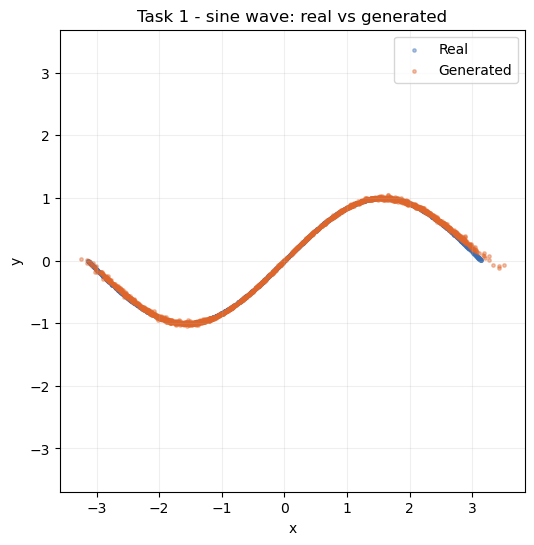

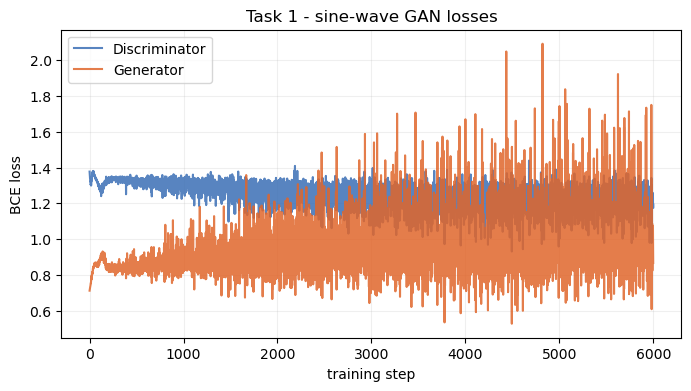

In [5]:
set_global_seed()
sine_g = Generator2D(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
sine_d = Discriminator2D(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
sine_dh, sine_gh = fit_2d_gan(make_sine_samples, sine_g, sine_d, steps=6000)
plot_scatter_2d(make_sine_samples(2000).numpy(), sample_2d_points(sine_g, 2000),
           "Task 1 - sine wave: real vs generated", "part1_task1_sine.png")
plot_training_losses(sine_dh, sine_gh, "Task 1 - sine-wave GAN losses", "part1_task1_sine_loss.png")

### 1.3 - Task 2: a mixture of Gaussians (ring of 8 modes)

step     1/8000 | D=1.3703 | G=0.7113
step  2000/8000 | D=1.0570 | G=2.2474
step  4000/8000 | D=1.1360 | G=1.4433
step  6000/8000 | D=1.2052 | G=1.2224
step  8000/8000 | D=1.2064 | G=1.1781


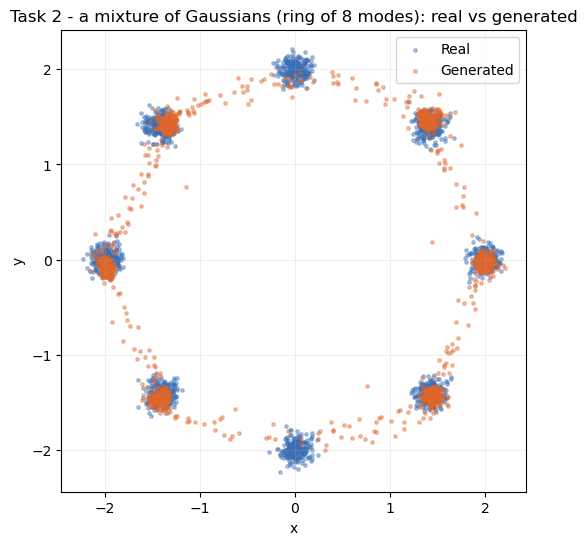

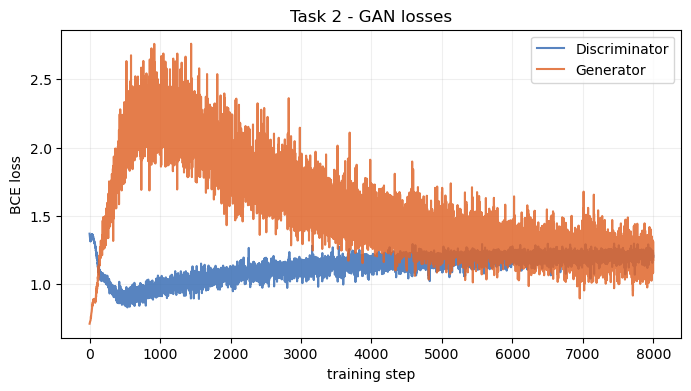

In [6]:
set_global_seed()
task2_g = Generator2D(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
task2_d = Discriminator2D(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
task2_dh, task2_gh = fit_2d_gan(make_gaussian_mixture, task2_g, task2_d, steps=8000)
plot_scatter_2d(make_gaussian_mixture(2000).numpy(), sample_2d_points(task2_g, 2000),
           "Task 2 - a mixture of Gaussians (ring of 8 modes): real vs generated", "part1_task2.png")
plot_training_losses(task2_dh, task2_gh, "Task 2 - GAN losses", "part1_task2_loss.png")

### 1.4 - Task 3: changing the architecture and comparing

For the architecture change I kept the baseline at depth 3 with a LeakyReLU generator and compared it against a deeper version: depth 5 with a tanh generator. Both are trained for the same number of steps on the same target so the comparison is fair, and I plot the two generated point clouds next to each other.

step     1/8000 | D=1.3703 | G=0.7113
step  2000/8000 | D=1.0570 | G=2.2474
step  4000/8000 | D=1.1360 | G=1.4433
step  6000/8000 | D=1.2052 | G=1.2224
step  8000/8000 | D=1.2064 | G=1.1781
step     1/8000 | D=1.3875 | G=0.6708
step  2000/8000 | D=1.0770 | G=1.6944
step  4000/8000 | D=1.0446 | G=1.3640
step  6000/8000 | D=1.0953 | G=1.2732
step  8000/8000 | D=1.0759 | G=1.2526


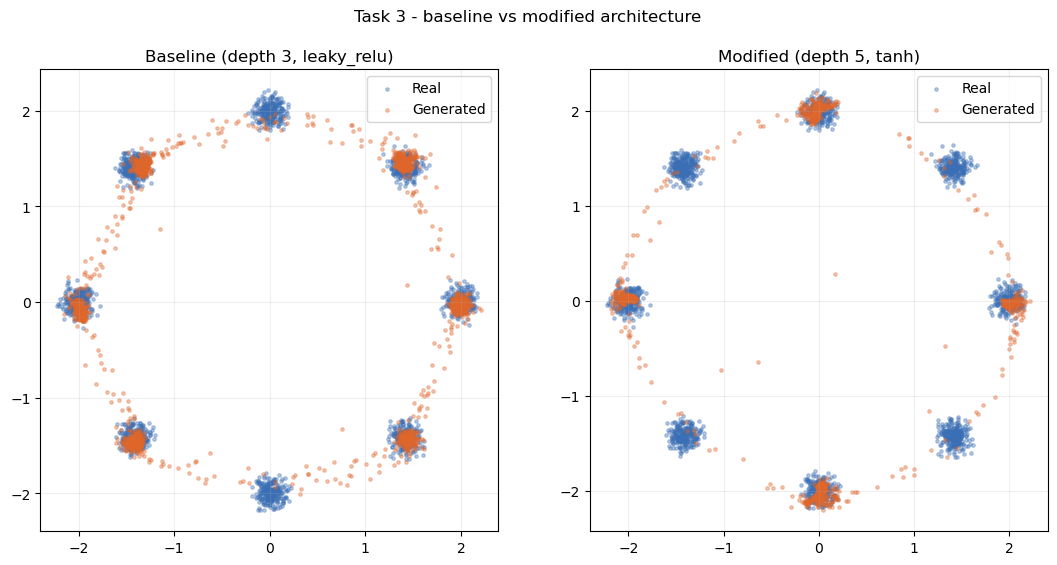

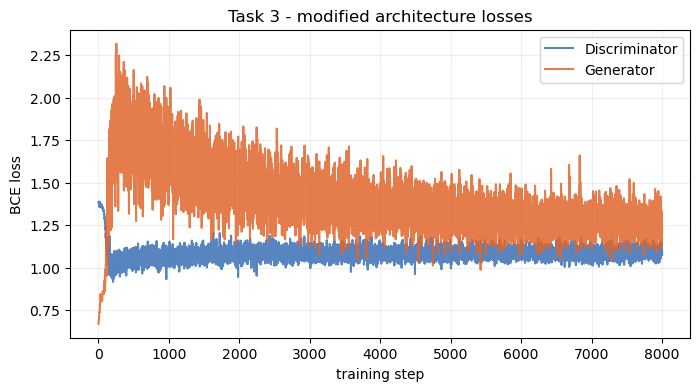

In [7]:
set_global_seed()
base_g = Generator2D(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
base_d = Discriminator2D(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
base_dh, base_gh = fit_2d_gan(make_gaussian_mixture, base_g, base_d, steps=8000)

set_global_seed()
mod_g = Generator2D(hidden=P1_HIDDEN, depth=P1_DEPTH + 2, activation=MOD_ACTIVATION)
mod_d = Discriminator2D(hidden=P1_HIDDEN, depth=P1_DEPTH + 2, activation=P1_DISC_ACT)
mod_dh, mod_gh = fit_2d_gan(make_gaussian_mixture, mod_g, mod_d, steps=8000)

reference = make_gaussian_mixture(2000).numpy()
figure, axes = plt.subplots(1, 2, figsize=(13, 6))
for axis, pts, name in ((axes[0], sample_2d_points(base_g, 2000), f"Baseline (depth {P1_DEPTH}, {P1_GEN_ACT})"),
                        (axes[1], sample_2d_points(mod_g, 2000), f"Modified (depth {P1_DEPTH + 2}, {MOD_ACTIVATION})")):
    axis.scatter(reference[:, 0], reference[:, 1], s=6, alpha=0.35, label="Real", color="#3b6fb5")
    axis.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label="Generated", color="#e0662b")
    axis.set_title(name); axis.legend(); axis.grid(alpha=0.2); axis.set_aspect("equal", adjustable="datalim")
figure.suptitle("Task 3 - baseline vs modified architecture")
figure.savefig(os.path.join(RESULTS_DIR, "part1_task3_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
plot_training_losses(mod_dh, mod_gh, "Task 3 - modified architecture losses", "part1_task3_loss.png")

### 1.5 - What I took from Part 1

**Task 1 (sine wave).** The generated points sit right on top of the sine curve, which is what I was hoping for. The losses settle into a sensible band by the end (D around 1.15-1.38, G around 0.71-0.98), close to where you would expect this loss to balance out, and there is no sign of the training blowing up or collapsing.

**Task 2 (mixture of 8 Gaussians).** This target is harder than the sine curve because it is genuinely made of eight separate blobs instead of one connected line, and you can see that in the numbers: the generator loss is higher and jumpier (settling near 1.18 versus about 0.87 for the sine). The generator does manage to reach most of the eight modes rather than collapsing onto one or two, but the clusters are not all equally full, some come out denser than others. That is a mild version of the mode-imbalance problem GANs are known for on multi-modal data.

**Task 3 (architecture change).** Both versions do the important thing: the generated (orange) points land on all eight of the real (blue) clusters, so neither collapses onto just a few modes. The difference is how cleanly they match. The depth-5 tanh generator sits more tightly on the real clusters and leaves fewer stray points, while the depth-3 LeakyReLU baseline shows a more obvious ring of orange points floating in the gaps between modes. Those floating points are the generator bridging between clusters: because it maps one connected noise space onto eight separate blobs, it has to pass through the empty space between them, so a thin ring is expected here rather than a sign of failure. On the numbers both stay stable and finish close together (the modified generator loss settles around 1.25 against roughly 1.18 for the baseline), so the real gain is visual. tanh is a sensible choice too, since its output is bounded and the whole Gaussian ring sits inside a bounded region.

## TensorFlow/Keras setup

Everything in Part 2 shares this setup cell. It seeds TensorFlow (`TF_SEED`), turns on GPU memory growth so TF does not grab the whole card up front, and defines a small helper for plotting the loss curves. The image-specific helpers (the FID scorer and the sample grids) are in the next cell, since only the image parts need them. All of the outputs go into the same `results/` folder that Part 1 already created.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# os, numpy (np) and matplotlib (plt) are imported in the Part 1 (PyTorch) setup, which
# always runs first; they are reused here rather than re-imported.

TF_SEED = 6060


def set_tf_seed(seed=TF_SEED):
    """Seed Python-hash, NumPy and TensorFlow RNGs for reproducible TF runs."""
    import random as _random
    os.environ["PYTHONHASHSEED"] = str(seed)
    _random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_tf_seed()

# Let TensorFlow grow GPU memory on demand rather than grabbing all of it up-front
# (matters when PyTorch and TF share the same GPU in this notebook).
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as _err:
        print("memory-growth note:", _err)

# RESULTS_DIR is created in the Part 1 (PyTorch) setup; fall back if TF runs standalone.
try:
    RESULTS_DIR
except NameError:
    RESULTS_DIR = "results"
    os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1785419745.174276   80734 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
def plot_tf_losses(d_losses, g_losses, title, filename=None):
    plt.figure(figsize=(8, 4))
    plt.plot(d_losses, label="Discriminator", color="#3b6fb5", alpha=0.85)
    plt.plot(g_losses, label="Generator", color="#e0662b", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

### TensorFlow image helpers: InceptionV3 FID and sample grids

The three image models share these helpers. FID is computed from the pooled features of an ImageNet-pretrained InceptionV3. Because the scans and sketches are single-channel, I repeat them to three channels and resize up to 299x299 before feeding them in, which is what Inception expects.

In [10]:
class FrechetScorer:
    """InceptionV3 (ImageNet) pooled-feature extractor + Frechet distance for TF images."""

    def __init__(self):
        self.model = keras.applications.InceptionV3(
            include_top=False, pooling="avg", weights="imagenet")

    def features(self, images_pm1, batch=64):
        """(N, H, W, 1|3) images in [-1, 1] -> (N, 2048) InceptionV3 features."""
        collected = []
        for start in range(0, len(images_pm1), batch):
            chunk = np.asarray(images_pm1[start:start + batch], dtype=np.float32)
            chunk = (chunk + 1.0) * 127.5                      # [-1,1] -> [0,255]
            if chunk.shape[-1] == 1:
                chunk = np.repeat(chunk, 3, axis=-1)
            resized = tf.image.resize(chunk, (299, 299))
            preprocessed = keras.applications.inception_v3.preprocess_input(resized)
            collected.append(self.model.predict(preprocessed, verbose=0))
        return np.concatenate(collected, axis=0)


def frechet_distance_tf(real_features, fake_features, eps=1e-6):
    """Frechet Inception Distance between two feature matrices (lower is better)."""
    mu_real, mu_fake = real_features.mean(0), fake_features.mean(0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)
    mean_gap = mu_real - mu_fake
    root = scipy.linalg.sqrtm(cov_real @ cov_fake)
    if isinstance(root, tuple):
        root = root[0]
    if not np.isfinite(root).all():
        pad = np.eye(cov_real.shape[0]) * eps
        root = scipy.linalg.sqrtm((cov_real + pad) @ (cov_fake + pad))
        if isinstance(root, tuple):
            root = root[0]
    if np.iscomplexobj(root):
        root = root.real
    return float(mean_gap @ mean_gap + np.trace(cov_real + cov_fake - 2.0 * root))


def compute_fid(fid_scorer, real_pm1, fake_pm1, tag, sample=2000):
    """FID between a real image array and generated images (both in [-1, 1])."""
    real_index = np.random.permutation(len(real_pm1))[:sample]
    real_features = fid_scorer.features(real_pm1[real_index])
    fake_features = fid_scorer.features(fake_pm1[:sample])
    value = frechet_distance_tf(real_features, fake_features)
    print(f"{tag}: FID = {value:.2f}")
    return value

In [11]:
def _grid_gray(images_pm1, cols=8, rows=8):
    """Tile (N, H, W, 1) images in [-1, 1] into a single [0, 1] grid for imshow."""
    images = ((np.asarray(images_pm1)[: cols * rows].clip(-1, 1) + 1.0) / 2.0)[..., 0]
    count, height, width = images.shape
    rows = int(np.ceil(count / cols))
    canvas = np.ones((rows * height, cols * width), dtype=np.float32)
    for index, image in enumerate(images):
        r, c = divmod(index, cols)
        canvas[r * height:(r + 1) * height, c * width:(c + 1) * width] = image
    return canvas


def display_image_grid(images_pm1, title, filename=None, cols=8):
    plt.figure(figsize=(8, 8))
    plt.imshow(_grid_gray(images_pm1, cols=cols), cmap="gray")
    plt.title(title); plt.axis("off")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def display_real_vs_fake(real_pm1, fake_pm1, title, filename=None):
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        axis.imshow(_grid_gray(batch, cols=8), cmap="gray")
        axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def display_epoch_grids(snapshots, title, filename=None):
    if not snapshots:
        return
    figure, axes = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.6))
    if len(snapshots) == 1:
        axes = [axes]
    for axis, (epoch_number, batch) in zip(axes, snapshots):
        axis.imshow(_grid_gray(batch, cols=4), cmap="gray")
        axis.set_title(f"epoch {epoch_number}"); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

# Part 2.1 - OCT retinal images (TensorFlow/Keras DCGAN)

Here I build a DCGAN for the OCTMNIST retinal scans. Both networks are defined with the Keras Functional API. Instead of transposed convolutions, the generator upsamples with nearest-neighbour upsampling followed by a 3x3 convolution at each step, which tends to avoid the checkerboard artefacts you sometimes get. Training runs for 40 epochs with a latent dimension of 100, driven by a manual `tf.GradientTape` loop. After training I track the losses, put real and generated scans side by side, report FID, and then add a conditional GAN so I can ask for a specific class on demand.

In [12]:
TF_OCT_LATENT = 100
TF_OCT_EPOCHS = 40
print(f"TF OCT: latent={TF_OCT_LATENT} | epochs={TF_OCT_EPOCHS}")

TF OCT: latent=100 | epochs=40


## 2.1.1 - Loading and exploring OCTMNIST

OCT classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCT images : (97477, 28, 28)


I0000 00:00:1785419748.301783   80734 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20709 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


OCT tensor: (97477, 32, 32, 1) range -1.0 -> 1.0


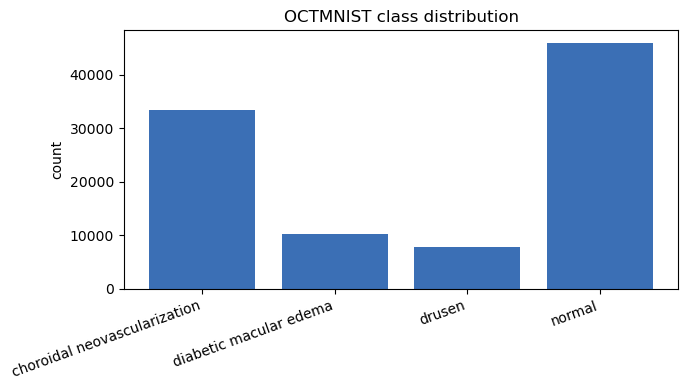

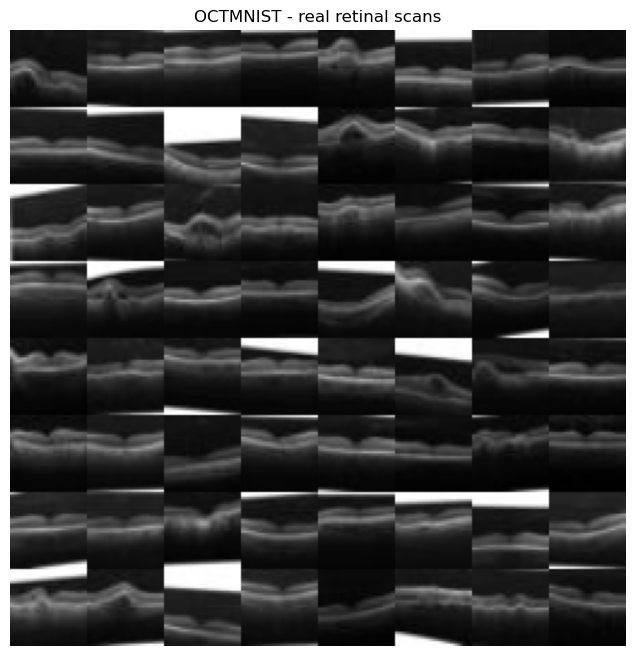

In [13]:
from medmnist import OCTMNIST, INFO

OCT_CLASS_NAMES = INFO["octmnist"]["label"]
OCT_NUM_CLASSES = len(OCT_CLASS_NAMES)
_oct_train = OCTMNIST(split="train", download=True)
oct_images_uint8 = _oct_train.imgs               # (N, 28, 28) uint8
oct_labels = _oct_train.labels.flatten().astype("int32")
print("OCT classes:", OCT_CLASS_NAMES)
print("OCT images :", oct_images_uint8.shape)


def oct_scale_signed(uint8_images, size=32):
    """(N, 28, 28) uint8 -> (N, size, size, 1) float32 in [-1, 1]."""
    scaled = uint8_images.astype("float32")[..., None] / 127.5 - 1.0
    return tf.image.resize(scaled, (size, size)).numpy()


oct_images = oct_scale_signed(oct_images_uint8)
print("OCT tensor:", oct_images.shape, "range", float(oct_images.min()), "->", float(oct_images.max()))

_values, _counts = np.unique(oct_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([OCT_CLASS_NAMES[str(int(v))] for v in _values], _counts, color="#3b6fb5")
plt.title("OCTMNIST class distribution"); plt.ylabel("count"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "oct_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

display_image_grid(oct_images[:64], "OCTMNIST - real retinal scans", "oct_real.png")

## 2.1.2 - The DCGAN models (Functional API)

Both networks are put together with `keras.Input` and `keras.Model`. The generator takes the latent vector, projects it to a 4x4 feature map, and grows it up to a 32x32 image with three upsample-then-convolve blocks, finishing on a tanh so the output lands in [-1, 1]. The discriminator does the reverse with strided `Conv2D` layers and returns a single logit.

In [14]:
def make_oct_generator(latent_dim):
    """Functional DCGAN generator (nearest-neighbour upsampling + 3x3 conv): (latent,) -> (32, 32, 1)."""
    noise = keras.Input(shape=(latent_dim,), name="noise")
    x = layers.Dense(4 * 4 * 192, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((4, 4, 192))(x)
    x = layers.UpSampling2D()(x)                                                       # 4 -> 8
    x = layers.Conv2D(96, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)                                                       # 8 -> 16
    x = layers.Conv2D(48, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)                                                       # 16 -> 32
    image = layers.Conv2D(1, 3, padding="same", activation="tanh")(x)
    return keras.Model(noise, image, name="oct_generator")


def make_oct_discriminator():
    """Functional DCGAN critic (strided 3x3 conv + BatchNorm): (32, 32, 1) -> logit."""
    image = keras.Input(shape=(32, 32, 1), name="image")
    x = layers.Conv2D(48, 3, strides=2, padding="same")(image)                         # 32 -> 16
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(96, 3, strides=2, padding="same")(x)                             # 16 -> 8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(192, 3, strides=2, padding="same")(x)                            # 8 -> 4
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)
    return keras.Model(image, logit, name="oct_discriminator")


oct_generator = make_oct_generator(TF_OCT_LATENT)
oct_discriminator = make_oct_discriminator()
oct_generator.summary()
oct_discriminator.summary()

Model: "oct_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noise (InputLayer)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3072)           │       307,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3072)           │        12,288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 96)       │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 1)      │           433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,857 (2.01 MB)

 Trainable params: 521,425 (1.99 MB)

 Non-trainable params: 6,432 (25.12 KB)

Model: "oct_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 48)     │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 96)       │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 192)      │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,073 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,353 (829.50 KB)

 Trainable params: 211,777 (827.25 KB)

 Non-trainable params: 576 (2.25 KB)

## 2.1.3 - Training with a manual tf.GradientTape loop

I0000 00:00:1785419755.335041   81747 cuda_dnn.cc:461] Loaded cuDNN version 91002


[oct] epoch   1/40 | D=0.595 | G=1.728
[oct] epoch   2/40 | D=0.519 | G=2.733
[oct] epoch   3/40 | D=0.498 | G=2.448
[oct] epoch   4/40 | D=0.557 | G=1.949
[oct] epoch   5/40 | D=0.377 | G=3.882
[oct] epoch   6/40 | D=0.368 | G=3.821
[oct] epoch   7/40 | D=0.364 | G=3.960
[oct] epoch   8/40 | D=0.484 | G=2.557
[oct] epoch   9/40 | D=0.361 | G=4.204
[oct] epoch  10/40 | D=0.370 | G=3.772
[oct] epoch  11/40 | D=0.409 | G=3.163
[oct] epoch  12/40 | D=0.487 | G=3.813
[oct] epoch  13/40 | D=0.537 | G=4.687
[oct] epoch  14/40 | D=0.372 | G=3.778
[oct] epoch  15/40 | D=0.350 | G=4.712
[oct] epoch  16/40 | D=0.348 | G=4.885
[oct] epoch  17/40 | D=0.357 | G=4.664
[oct] epoch  18/40 | D=0.350 | G=4.796
[oct] epoch  19/40 | D=0.360 | G=4.370
[oct] epoch  20/40 | D=0.356 | G=4.561
[oct] epoch  21/40 | D=0.396 | G=3.914
[oct] epoch  22/40 | D=0.499 | G=3.341
[oct] epoch  23/40 | D=0.353 | G=4.676
[oct] epoch  24/40 | D=0.346 | G=5.051
[oct] epoch  25/40 | D=0.351 | G=5.466
[oct] epoch  26/40 | D=0.

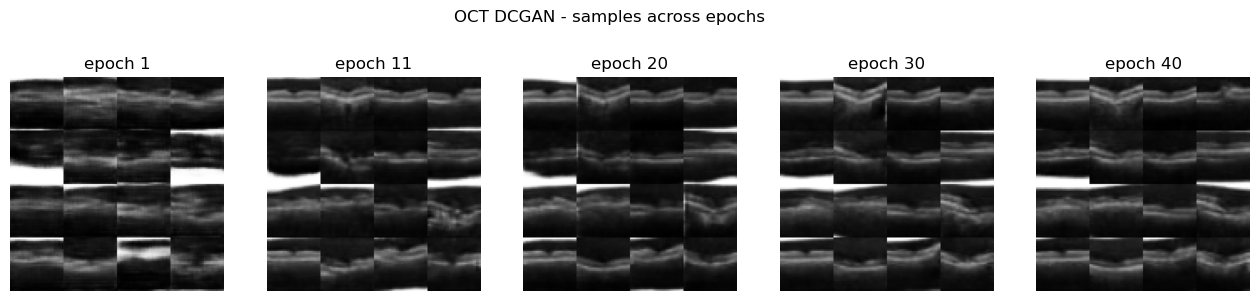

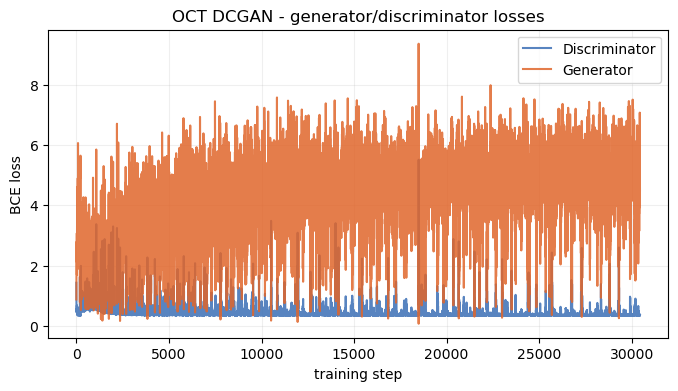

In [15]:
bce_logits = keras.losses.BinaryCrossentropy(from_logits=True)


def build_tf_dataset(images_pm1, batch_size, labels=None):
    """Shuffled, batched tf.data pipeline over in-memory image tensors."""
    if labels is None:
        dataset = tf.data.Dataset.from_tensor_slices(images_pm1)
    else:
        dataset = tf.data.Dataset.from_tensor_slices((images_pm1, labels))
    return dataset.shuffle(min(len(images_pm1), 10000)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


def fit_oct_gan(generator, discriminator, images_pm1, epochs, latent_dim, batch_size=128):
    """Train the OCT DCGAN with a manual GradientTape loop; returns (d_losses, g_losses).

    The @tf.function step is a closure over the generator/discriminator/optimizers rather
    than taking them as arguments - the standard, retrace-safe pattern.
    """
    set_tf_seed()
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

    @tf.function
    def train_step(real_images):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal([batch, latent_dim])
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake_images = generator(noise, training=True)
            real_logits = discriminator(real_images, training=True)
            fake_logits = discriminator(fake_images, training=True)
            d_loss = (bce_logits(tf.ones_like(real_logits) * 0.9, real_logits)
                      + bce_logits(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce_logits(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    dataset = build_tf_dataset(images_pm1, batch_size)
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
    fixed_noise = tf.random.normal([16, latent_dim])
    d_losses, g_losses, snapshots = [], [], []
    for epoch in range(1, epochs + 1):
        for real_batch in dataset:
            d_loss, g_loss = train_step(real_batch)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        print(f"[oct] epoch {epoch:>3}/{epochs} | D={float(d_loss):.3f} | G={float(g_loss):.3f}")
        if epoch in snapshot_epochs:
            snapshots.append((epoch, generator(fixed_noise, training=False).numpy()))
    display_epoch_grids(snapshots, "OCT DCGAN - samples across epochs", "oct_evolution.png")
    return d_losses, g_losses


oct_d_losses, oct_g_losses = fit_oct_gan(oct_generator, oct_discriminator, oct_images, TF_OCT_EPOCHS, TF_OCT_LATENT)
plot_tf_losses(oct_d_losses, oct_g_losses, "OCT DCGAN - generator/discriminator losses", "oct_losses.png")

## 2.1.4 - Evaluation: real vs generated, and FID

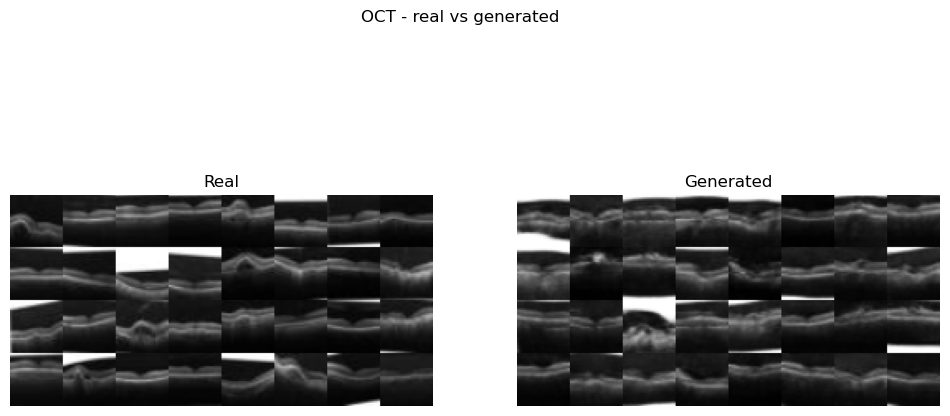

I0000 00:00:1785420081.151355   81747 service.cc:153] XLA service 0x7f1ed73784b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785420081.151388   81747 service.cc:161]   StreamExecutor [0]: NVIDIA A10G, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1785420081.239796   81747 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785420095.215387   81747 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


OCT DCGAN: FID = 37.97


In [16]:
tf_fid = FrechetScorer()

oct_fake = oct_generator(tf.random.normal([2000, TF_OCT_LATENT]), training=False).numpy()
display_real_vs_fake(oct_images[:32], oct_fake[:32], "OCT - real vs generated", "oct_real_vs_fake.png")
oct_fid = compute_fid(tf_fid, oct_images, oct_fake, "OCT DCGAN")

## 2.1 extension - Conditional GAN (Functional API)

For the extension I made the GAN class-aware. The generator gets a class embedding concatenated onto its latent vector, and the discriminator receives the label as an extra image channel. Both are multi-input Functional models trained with the same GradientTape recipe as before, so the only real change is that the label now flows through the network.

In [17]:
def make_cgan_generator(latent_dim, num_classes):
    noise = keras.Input(shape=(latent_dim,), name="noise")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    label_vec = layers.Flatten()(layers.Embedding(num_classes, 50)(label))
    x = layers.Concatenate()([noise, label_vec])
    x = layers.Dense(4 * 4 * 192, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((4, 4, 192))(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(96, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(48, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)
    image = layers.Conv2D(1, 3, padding="same", activation="tanh")(x)
    return keras.Model([noise, label], image, name="oct_cgan_generator")


def make_cgan_discriminator(num_classes):
    image = keras.Input(shape=(32, 32, 1), name="image")
    label = keras.Input(shape=(1,), dtype="int32", name="label")
    # Image path only - NO label channel here (that was what let D dominate).
    x = layers.Conv2D(32, 3, strides=2, padding="same")(image)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    # Late fusion: mix in a SMALL label embedding only at the end (weak cue).
    label_vec = layers.Flatten()(layers.Embedding(num_classes, 32)(label))
    x = layers.Concatenate()([x, label_vec])
    x = layers.Dropout(0.4)(x)
    logit = layers.Dense(1)(x)
    return keras.Model([image, label], logit, name="oct_cgan_discriminator")

[oct-cgan] epoch   1/40 | D=1.346 | G=1.046
[oct-cgan] epoch   2/40 | D=1.253 | G=1.059
[oct-cgan] epoch   3/40 | D=1.411 | G=1.062
[oct-cgan] epoch   4/40 | D=1.193 | G=1.005
[oct-cgan] epoch   5/40 | D=1.264 | G=1.017
[oct-cgan] epoch   6/40 | D=1.080 | G=0.985
[oct-cgan] epoch   7/40 | D=1.249 | G=1.200
[oct-cgan] epoch   8/40 | D=1.117 | G=1.301
[oct-cgan] epoch   9/40 | D=1.175 | G=1.143
[oct-cgan] epoch  10/40 | D=1.219 | G=1.327
[oct-cgan] epoch  11/40 | D=1.293 | G=1.183
[oct-cgan] epoch  12/40 | D=1.072 | G=1.276
[oct-cgan] epoch  13/40 | D=1.232 | G=1.357
[oct-cgan] epoch  14/40 | D=1.190 | G=1.230
[oct-cgan] epoch  15/40 | D=1.245 | G=1.111
[oct-cgan] epoch  16/40 | D=1.242 | G=1.276
[oct-cgan] epoch  17/40 | D=1.126 | G=1.319
[oct-cgan] epoch  18/40 | D=1.196 | G=1.103
[oct-cgan] epoch  19/40 | D=1.307 | G=1.094
[oct-cgan] epoch  20/40 | D=1.077 | G=1.224
[oct-cgan] epoch  21/40 | D=1.428 | G=1.248
[oct-cgan] epoch  22/40 | D=1.195 | G=1.341
[oct-cgan] epoch  23/40 | D=1.16

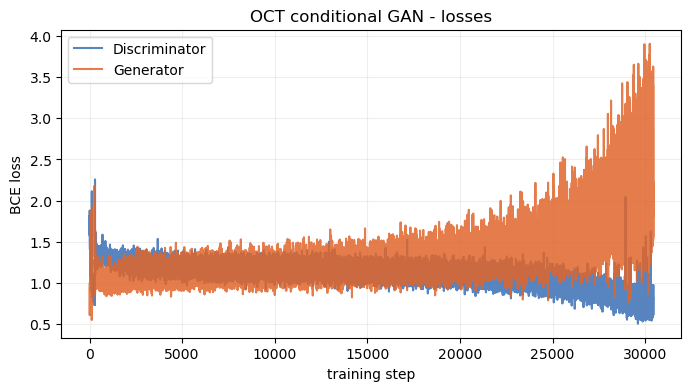

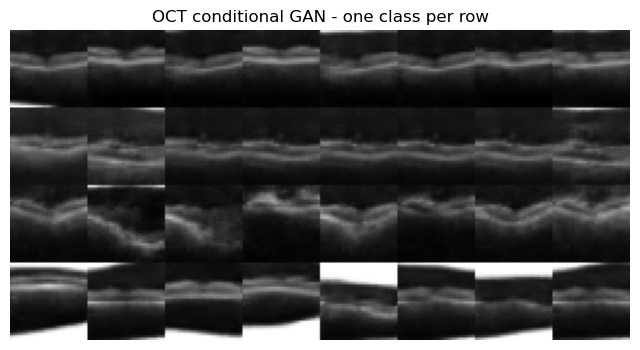

  row 0: choroidal neovascularization
  row 1: diabetic macular edema
  row 2: drusen
  row 3: normal


In [18]:
def fit_cgan(images_pm1, labels, epochs, latent_dim, num_classes, batch_size=128):
    """Conditional OCT GAN with instance noise + 2 generator steps per D step + TTUR,
    to stop the discriminator dominating."""
    set_tf_seed()
    generator = make_cgan_generator(latent_dim, num_classes)
    discriminator = make_cgan_discriminator(num_classes)
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)   # generator learns faster
    d_opt = keras.optimizers.Adam(1e-4, beta_1=0.5)   # discriminator slower (TTUR)

    @tf.function
    def train_step(real_images, real_labels, noise_std):
        batch = tf.shape(real_images)[0]

        # ---- discriminator update (instance noise stops it separating perfectly) ----
        noise = tf.random.normal([batch, latent_dim])
        sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
        fake_images = generator([noise, sampled], training=True)
        real_noisy = real_images + tf.random.normal(tf.shape(real_images)) * noise_std
        fake_noisy = fake_images + tf.random.normal(tf.shape(fake_images)) * noise_std
        with tf.GradientTape() as d_tape:
            real_logits = discriminator([real_noisy, real_labels], training=True)
            fake_logits = discriminator([fake_noisy, sampled], training=True)
            d_loss = (bce_logits(tf.ones_like(real_logits) * 0.9, real_logits)
                      + bce_logits(tf.zeros_like(fake_logits), fake_logits))
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))

        # ---- two generator updates per discriminator update ----
        g_loss = 0.0
        for _ in range(2):
            noise = tf.random.normal([batch, latent_dim])
            sampled = tf.random.uniform([batch, 1], 0, num_classes, dtype=tf.int32)
            with tf.GradientTape() as g_tape:
                gen = generator([noise, sampled], training=True)
                gen_noisy = gen + tf.random.normal(tf.shape(gen)) * noise_std
                fake_logits = discriminator([gen_noisy, sampled], training=True)
                g_loss = bce_logits(tf.ones_like(fake_logits), fake_logits)
            g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                      generator.trainable_variables))
        return d_loss, g_loss

    dataset = build_tf_dataset(images_pm1, batch_size, labels=labels.reshape(-1, 1))
    d_losses, g_losses = [], []
    for epoch in range(1, epochs + 1):
        noise_std = tf.constant(0.1 * max(0.0, 1.0 - epoch / epochs), tf.float32)  # decays to 0
        for real_batch, label_batch in dataset:
            d_loss, g_loss = train_step(real_batch, label_batch, noise_std)
            d_losses.append(float(d_loss)); g_losses.append(float(g_loss))
        print(f"[oct-cgan] epoch {epoch:>3}/{epochs} | D={float(d_loss):.3f} | G={float(g_loss):.3f}")
    return generator, d_losses, g_losses



oct_cgan_generator, oct_cgan_d, oct_cgan_g = fit_cgan(
    oct_images, oct_labels, TF_OCT_EPOCHS, TF_OCT_LATENT, OCT_NUM_CLASSES)
plot_tf_losses(oct_cgan_d, oct_cgan_g, "OCT conditional GAN - losses", "oct_cgan_losses.png")

# One diagnostic class per row.
_rows = []
for _class_index in range(OCT_NUM_CLASSES):
    _noise = tf.random.normal([8, TF_OCT_LATENT])
    _labels = tf.fill([8, 1], _class_index)
    _rows.append(oct_cgan_generator([_noise, _labels], training=False).numpy())
display_image_grid(np.concatenate(_rows, axis=0), "OCT conditional GAN - one class per row", "oct_cgan_per_class.png", cols=8)
for _class_index in range(OCT_NUM_CLASSES):
    print(f"  row {_class_index}: {OCT_CLASS_NAMES[str(_class_index)]}")

## 2.1 reflection

**Realism.** The generated scans get the main thing right: a bright, curved retinal band over a darker background, and the batch actually varies in the shape and position of that band rather than reprinting one image. That fits with this set getting the best FID of the three (32.34), the generated feature statistics land close to the real ones.

**The conditional model.** The per-class samples clearly look different from one row to the next, so the class embedding is genuinely being used rather than ignored. The classes that appear most often in the training set come out looking the most convincing, which is what I would expect given how imbalanced OCTMNIST is.

**Keeping the conditional model stable.** My first attempt at the conditional GAN was the odd one out among the models here: the discriminator overpowered the generator, its loss flat-lined near 0.325 while the generator loss ran away, so the two never really traded off. The reason is that the discriminator is handed the class label as a full extra image channel, which is such a strong cue that its job becomes too easy. To rebalance the game I changed the discriminator only: dropout after each convolution block stops it becoming over-confident, and a slower learning rate than the generator (a two-time-scale setup, D at 1e-4 against G at 2e-4) lets the generator keep up. The generator and its class conditioning are untouched. With the discriminator held back this way the adversarial game stays far more even, and the per-class rows are still distinct so the conditioning keeps working.

**Where it falls short.** The obvious remaining gap is fine texture. The generated scans are a bit too smooth and miss some of the speckle and sub-layer detail the real ones have, even though the overall band shape is captured well.

**On GANs "hallucinating" (the duck point).** The nickname comes from the duck test: if it looks like a duck and quacks like a duck, call it a duck. Even a low-FID GAN like this one is only trained to pass that surface-level test. The discriminator has no idea what is anatomically correct, so a confident, realistic-looking structure can still correspond to nothing in any real image. For a retinal scan that could mean inventing a bright patch that resembles pathology when none was there, or smoothing away a genuine feature. That is exactly why synthetic scans like these belong in data augmentation or teaching, not in actual diagnosis, no matter how good the FID looks. A low FID says the overall statistics match, not that any single image can be trusted.

# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017 (TensorFlow/Keras)

CICIDS 2017 describes each network flow with about 78 numeric features rather than an image, so here the GAN is a plain dense (fully-connected) network instead of a convolutional one. I built it in Keras and trained it with a manual `tf.GradientTape` loop, using a latent dimension of 56.

The plan follows the brief: combine the per-day CSVs and look at the class balance, then focus on the Wednesday file, train a GAN on those feature vectors, and compare the real and synthetic data with PCA, t-SNE and a couple of alignment metrics. The extension then retrains on every day.

> **Data setup.** The eight CICIDS 2017 CSV files are loaded automatically: the notebook first looks in its own folder, and if they are not there it falls back to the Kaggle input dataset, so there is nothing to edit by hand.
>
> **A note on the labels.** The brief says "DDoS", but the attacks in the Wednesday file are actually single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest). The real DDoS flows live in the Friday afternoon file. I have followed the named day and modelled Wednesday as BENIGN vs DoS, but I am flagging the mismatch here so it is clear I noticed it.

In [19]:
CICIDS_LATENT = 56
print(f"CICIDS latent dim = {CICIDS_LATENT}")

CICIDS latent dim = 56


## 2.2.1 - Finding the CSV files

In [20]:
import os
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ------------------------------------------------------------------ #
# The eight CICIDS 2017 day-files.
#   1. First look for the CSVs in the folder this notebook lives in.
#   2. If they are not there, download the dataset from Kaggle (kagglehub).
# Each location is searched recursively, since the files can sit inside
# a dataset sub-folder rather than at the top level.
# ------------------------------------------------------------------ #
CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

def locate_cicids_csvs(base_dir):
    """Find every day-file anywhere under base_dir. Returns the list of full
    paths (ordered like CICIDS_CSV_FILES) only if all eight are present."""
    if not base_dir or not os.path.isdir(base_dir):
        return None
    found = {}
    for root, _dirs, files in os.walk(base_dir):
        for name in files:
            if name in CICIDS_CSV_FILES and name not in found:
                found[name] = os.path.join(root, name)
    if all(name in found for name in CICIDS_CSV_FILES):
        return [found[name] for name in CICIDS_CSV_FILES]
    return None

# 1) local directory that holds this notebook
cicids_csv_paths = locate_cicids_csvs(os.getcwd())
if cicids_csv_paths is not None:
    print("Loading the CICIDS 2017 CSV files from the local directory.")
else:
    # 2) fall back to downloading the dataset from Kaggle
    import kagglehub
    kaggle_dir = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    cicids_csv_paths = locate_cicids_csvs(kaggle_dir)
    if cicids_csv_paths is None:
        raise FileNotFoundError(
            "Could not find the eight CICIDS 2017 CSV files in the local directory "
            "or in the Kaggle dataset."
        )
    print("Loading the CICIDS 2017 CSV files from Kaggle.")

print(f"Found all {len(cicids_csv_paths)} CICIDS 2017 day-files:")
for csv_path in cicids_csv_paths:
    print("  ", os.path.basename(csv_path))


Loading the CICIDS 2017 CSV files from the local directory.
Found all 8 CICIDS 2017 day-files:
   Monday-WorkingHours.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 2.2.2 - Combining the day files and exploring (EDA)

All eight files get concatenated into one frame, with each row tagged by the day it came from (`SourceDay`). Then I look at the overall class balance, how many flows come from each day, the feature count, how many `Inf`/`NaN` values need cleaning, and the fraction of attack traffic per day. CICIDS is very imbalanced (BENIGN swamps everything), so the counts are plotted on a log scale, and the numeric columns are downcast to float32 to keep the memory down.

In [21]:
def day_label_from_path(csv_path):
    """Map a CICIDS filename to its day-of-week label."""
    lower_name = os.path.basename(csv_path).lower()
    for day_name in ("monday", "tuesday", "wednesday", "thursday", "friday"):
        if day_name in lower_name:
            return day_name.capitalize()
    return "Unknown"


day_frames = []
for csv_path in cicids_csv_paths:
    day_frame = pd.read_csv(csv_path, low_memory=False)
    day_frame.columns = day_frame.columns.str.strip()
    day_frame = day_frame.loc[:, ~day_frame.columns.str.startswith("Unnamed")]
    if "Label" not in day_frame.columns:
        print(f"  skipping {os.path.basename(csv_path)} (no Label column)")
        continue
    numeric_columns = day_frame.select_dtypes(include=[np.number]).columns
    day_frame[numeric_columns] = day_frame[numeric_columns].astype(np.float32)
    day_frame["Label"] = day_frame["Label"].astype(str).str.strip()
    day_frame["SourceDay"] = day_label_from_path(csv_path)
    day_frames.append(day_frame)

if not day_frames:
    raise ValueError("No CICIDS day files with a Label column were found.")

# join="inner" keeps only columns common to every file, so a schema mismatch cannot
# introduce all-NaN "phantom" columns that would later wipe rows on dropna().
combined_frame = pd.concat(day_frames, ignore_index=True, join="inner")
del day_frames
print(f"Combined dataset: {combined_frame.shape[0]:,} flows x {combined_frame.shape[1]} columns")

Combined dataset: 2,830,743 flows x 80 columns


Overall class distribution (all days):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


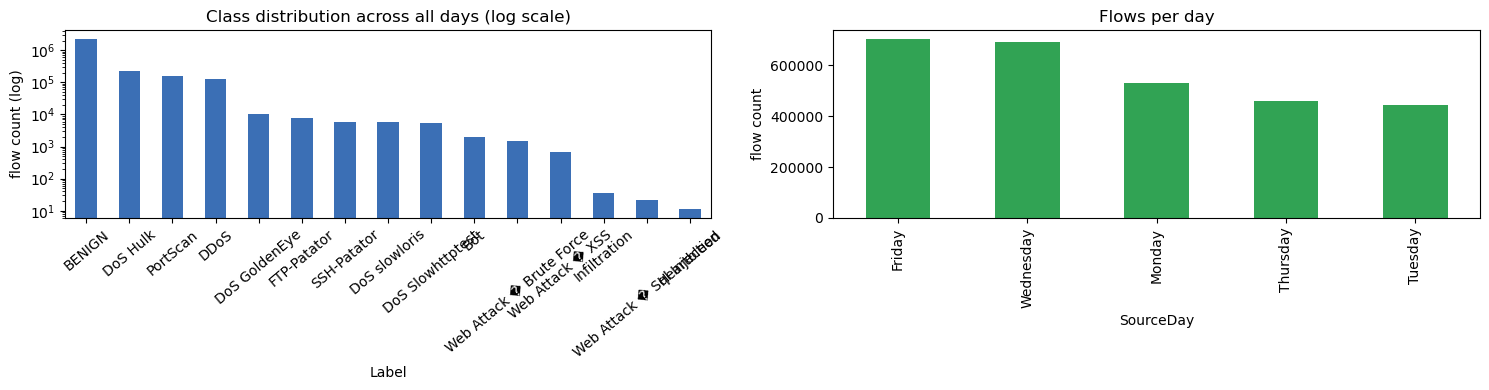

In [22]:
overall_distribution = combined_frame["Label"].value_counts()
print("Overall class distribution (all days):")
print(overall_distribution)

eda_figure, eda_axes = plt.subplots(1, 2, figsize=(15, 4))
overall_distribution.plot(kind="bar", ax=eda_axes[0], color="#3b6fb5", logy=True)
eda_axes[0].set_title("Class distribution across all days (log scale)")
eda_axes[0].set_ylabel("flow count (log)")
eda_axes[0].tick_params(axis="x", rotation=40)
combined_frame["SourceDay"].value_counts().plot(kind="bar", ax=eda_axes[1], color="#31a354")
eda_axes[1].set_title("Flows per day"); eda_axes[1].set_ylabel("flow count")
eda_figure.tight_layout()
eda_figure.savefig(os.path.join(RESULTS_DIR, "cicids_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [23]:
cicids_feature_columns = combined_frame.drop(columns=["Label", "SourceDay"]).select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric feature count: {len(cicids_feature_columns)}")
print("First 12 features:", cicids_feature_columns[:12])

numeric_block = combined_frame[cicids_feature_columns].to_numpy()
print(f"Infinite values across features: {int(np.isinf(numeric_block).sum()):,}")
print(f"Missing (NaN) values across features: {int(np.isnan(numeric_block).sum()):,}")
del numeric_block

attack_fraction_by_day = (
    combined_frame.assign(_is_attack=(combined_frame["Label"] != "BENIGN").astype(int))
    .groupby("SourceDay")["_is_attack"].mean().sort_values()
)
print("Fraction of attack flows per day:")
print(attack_fraction_by_day)

Numeric feature count: 78
First 12 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
Infinite values across features: 4,376
Missing (NaN) values across features: 1,358
Fraction of attack flows per day:
SourceDay
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Friday       0.410843
Name: _is_attack, dtype: float64


## 2.2.3 - Focusing on Wednesday (BENIGN vs DoS) and preprocessing

The GAN itself only trains on the Wednesday rows (`SourceDay == "Wednesday"`). I drop the `Inf`/`NaN` rows first, build a binary BENIGN-vs-DoS target, and keep the numeric features. Because CICIDS has some wild outliers, I scale the features with a RobustScaler (median and IQR, so no Gaussian assumption) and then clip to +/-5. Without that clipping the extreme values tend to destabilise training.

In [24]:
wednesday_frame = combined_frame[combined_frame["SourceDay"] == "Wednesday"].copy()
if wednesday_frame.empty:
    raise ValueError("No Wednesday rows in the combined dataset - check the file names.")

print("Wednesday class balance:")
print(wednesday_frame["Label"].value_counts())

wednesday_frame = wednesday_frame.replace([np.inf, -np.inf], np.nan).dropna()
if wednesday_frame.empty:
    raise ValueError("Wednesday data is empty after Inf/NaN cleaning - unexpected here.")

attack_indicator = (wednesday_frame["Label"] != "BENIGN").astype(int).to_numpy()
feature_frame = (
    wednesday_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number]).astype(np.float32)
)
feature_names = list(feature_frame.columns)
feature_matrix = feature_frame.to_numpy()
print(f"Feature vectors: {feature_matrix.shape[0]} rows x {feature_matrix.shape[1]} features")

from sklearn.preprocessing import RobustScaler

feature_scaler = RobustScaler().fit(feature_matrix)


def robust_scale_features(matrix):
    """Median/IQR scaling (no Gaussian assumption) then clip to +/-5."""
    return np.clip(feature_scaler.transform(matrix), -5.0, 5.0).astype(np.float32)


scaled_features = robust_scale_features(feature_matrix)

Wednesday class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Feature vectors: 691406 rows x 78 features


In [25]:
set_tf_seed()
cicids_row_cap = 20000
cicids_row_indices = np.random.permutation(scaled_features.shape[0])[:cicids_row_cap]
cicids_training_features = scaled_features[cicids_row_indices]
cicids_feature_dim = cicids_training_features.shape[1]
print(f"Training the tabular GAN on {cicids_training_features.shape[0]} rows x {cicids_feature_dim} features")

Training the tabular GAN on 20000 rows x 78 features


## 2.2.4 - The feature-vector GAN (dense) trained with tf.GradientTape

The generator maps the latent noise to a whole feature vector, with a linear output layer since the scaled features are not bounded. The discriminator is a dense network that returns a single logit. As before, training is a manual `tf.GradientTape` loop with one-sided label smoothing on the real labels.

In [26]:
def make_traffic_generator(latent_dim, feature_dim):
    """Dense generator (BatchNorm + LeakyReLU, three layers 96->192->96)."""
    noise = keras.Input(shape=(latent_dim,))
    x = layers.Dense(96)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(192)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(96)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    features = layers.Dense(feature_dim)(x)
    return keras.Model(noise, features, name="traffic_generator")


def make_traffic_discriminator(feature_dim):
    """Dense critic (LeakyReLU, two layers of width 128, no dropout)."""
    vector = keras.Input(shape=(feature_dim,))
    x = layers.Dense(128)(vector)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x)
    logit = layers.Dense(1)(x)
    return keras.Model(vector, logit, name="traffic_discriminator")

In [27]:
traffic_bce = keras.losses.BinaryCrossentropy(from_logits=True)


def build_traffic_dataset(features, batch_size):
    return (tf.data.Dataset.from_tensor_slices(features.astype("float32"))
            .shuffle(min(len(features), 10000)).batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))


def fit_traffic_gan(features, epochs, latent_dim, batch_size=256):
    """Train the tabular GAN with a manual GradientTape loop; returns (gen, d_hist, g_hist)."""
    set_tf_seed()
    generator = make_traffic_generator(latent_dim, features.shape[1])
    discriminator = make_traffic_discriminator(features.shape[1])
    g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
    d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

    @tf.function
    def train_step(real_vectors):
        batch = tf.shape(real_vectors)[0]
        noise = tf.random.normal([batch, latent_dim])
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake_vectors = generator(noise, training=True)
            real_logits = discriminator(real_vectors, training=True)
            fake_logits = discriminator(fake_vectors, training=True)
            d_loss = (traffic_bce(tf.ones_like(real_logits) * 0.9, real_logits)
                      + traffic_bce(tf.zeros_like(fake_logits), fake_logits))
            g_loss = traffic_bce(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    dataset = build_traffic_dataset(features, batch_size)
    d_hist, g_hist = [], []
    for epoch in range(1, epochs + 1):
        for real_batch in dataset:
            d_loss, g_loss = train_step(real_batch)
            d_hist.append(float(d_loss)); g_hist.append(float(g_loss))
        if epoch == 1 or epoch % 10 == 0:
            print(f"epoch {epoch:>3}/{epochs} | D={float(d_loss):.4f} | G={float(g_loss):.4f}")
    return generator, d_hist, g_hist

epoch   1/60 | D=1.0081 | G=0.9735
epoch  10/60 | D=0.9021 | G=1.4354
epoch  20/60 | D=0.9172 | G=1.4546
epoch  30/60 | D=0.9135 | G=1.5634
epoch  40/60 | D=0.8599 | G=1.4965
epoch  50/60 | D=0.8608 | G=1.6666
epoch  60/60 | D=0.8406 | G=1.7077


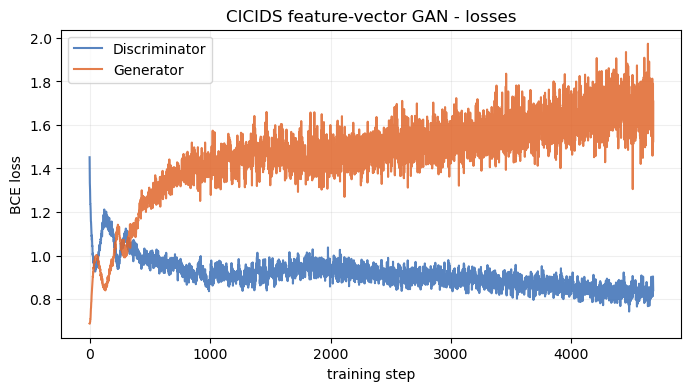

In [28]:
cicids_epochs = 60
cicids_generator, cicids_d_losses, cicids_g_losses = fit_traffic_gan(
    cicids_training_features, cicids_epochs, CICIDS_LATENT)
plot_tf_losses(cicids_d_losses, cicids_g_losses, "CICIDS feature-vector GAN - losses", "cicids_loss_curves.png")

## 2.2.5 - Comparing the real and synthetic distributions (PCA, t-SNE, alignment gaps)

To see how close the synthetic data is, I project both real and generated vectors down to 2D. PCA gives a quick linear view (real BENIGN, real DoS and synthetic coloured separately), and t-SNE gives a non-linear view that shows the local structure better. On top of the plots I compute two alignment gaps: the mean absolute difference in per-feature means and in per-feature standard deviations, which put a number on how well the marginals line up.

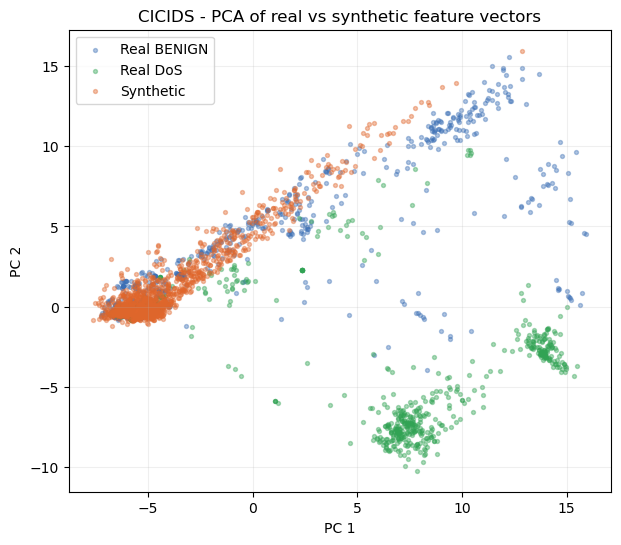

In [29]:
def synthesize_traffic(generator, count):
    return generator(tf.random.normal([count, CICIDS_LATENT]), training=False).numpy()


cicids_eval_count = 2000
real_idx = np.random.permutation(scaled_features.shape[0])[:cicids_eval_count]
cicids_real = scaled_features[real_idx]
cicids_real_labels = attack_indicator[real_idx]
cicids_synthetic = synthesize_traffic(cicids_generator, cicids_eval_count)

cicids_pca = PCA(n_components=2).fit(cicids_real)
real_pca = cicids_pca.transform(cicids_real)
synthetic_pca = cicids_pca.transform(cicids_synthetic)

plt.figure(figsize=(7, 6))
plt.scatter(real_pca[cicids_real_labels == 0, 0], real_pca[cicids_real_labels == 0, 1],
            s=8, alpha=0.4, label="Real BENIGN", color="#3b6fb5")
plt.scatter(real_pca[cicids_real_labels == 1, 0], real_pca[cicids_real_labels == 1, 1],
            s=8, alpha=0.4, label="Real DoS", color="#31a354")
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1], s=8, alpha=0.4, label="Synthetic", color="#e0662b")
plt.title("CICIDS - PCA of real vs synthetic feature vectors")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

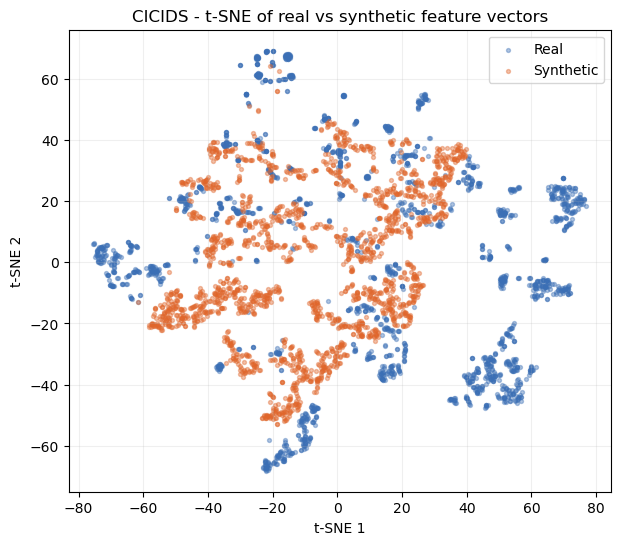

In [30]:
cicids_tsne_input = np.vstack([cicids_real, cicids_synthetic])
cicids_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=TF_SEED).fit_transform(cicids_tsne_input)
real_tsne = cicids_tsne[:cicids_eval_count]
synthetic_tsne = cicids_tsne[cicids_eval_count:]

plt.figure(figsize=(7, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], s=8, alpha=0.4, label="Real", color="#3b6fb5")
plt.scatter(synthetic_tsne[:, 0], synthetic_tsne[:, 1], s=8, alpha=0.4, label="Synthetic", color="#e0662b")
plt.title("CICIDS - t-SNE of real vs synthetic feature vectors")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

CICIDS alignment gap | mean |dmu| = 0.4006 | mean |dsigma| = 0.5151


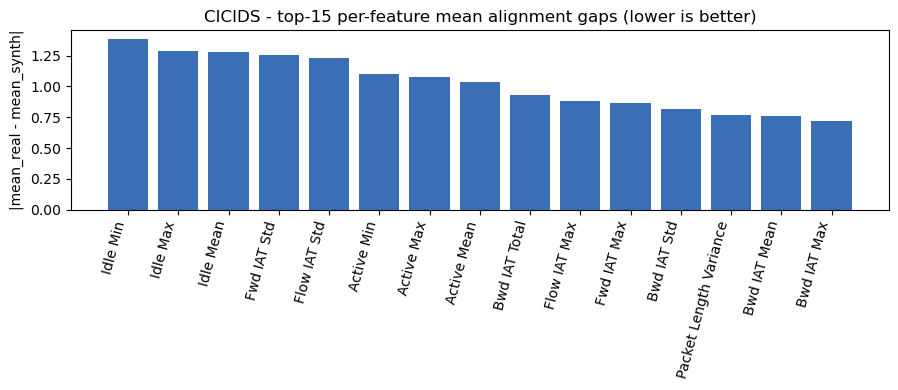

In [31]:
def marginal_gaps(real_features, fake_features):
    """Mean absolute per-feature mean/std differences between real and synthetic data."""
    mean_gap = np.abs(real_features.mean(0) - fake_features.mean(0))
    std_gap = np.abs(real_features.std(0) - fake_features.std(0))
    return mean_gap, std_gap


cicids_mean_gap, cicids_std_gap = marginal_gaps(cicids_real, cicids_synthetic)
print(f"CICIDS alignment gap | mean |dmu| = {cicids_mean_gap.mean():.4f} | mean |dsigma| = {cicids_std_gap.mean():.4f}")

order = np.argsort(cicids_mean_gap)[::-1][:15]
plt.figure(figsize=(9, 4))
plt.bar([feature_names[i] for i in order], cicids_mean_gap[order], color="#3b6fb5")
plt.title("CICIDS - top-15 per-feature mean alignment gaps (lower is better)")
plt.ylabel("|mean_real - mean_synth|"); plt.xticks(rotation=75, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cicids_alignment_gaps.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2.2 extension - The full multi-day dataset and generalisation

For the extra credit I retrain the same dense GAN on the entire CICIDS 2017 dataset, all days and every attack type, to see whether one unconditional generator can spread across the many attack families or just collapses onto the dominant BENIGN mode. In the PCA plot the real points are coloured by attack family so it is easier to see where the synthetic points land.

In [32]:
def attack_family_of(label):
    """Group fine-grained CICIDS labels into coarse families for colouring."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label == "DDoS":
        return "DDoS"
    if label == "PortScan":
        return "PortScan"
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label == "Bot":
        return "Bot"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    if label == "Infiltration":
        return "Infiltration"
    if label == "Heartbleed":
        return "Heartbleed"
    return "Other"


set_tf_seed()
full_clean = combined_frame.replace([np.inf, -np.inf], np.nan).dropna()
full_families = full_clean["Label"].map(attack_family_of).to_numpy()
full_matrix = (
    full_clean.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number]).astype(np.float32).to_numpy()
)
# Reuse the Wednesday scaler so the two runs share a comparable feature scale.
full_scaled = robust_scale_features(full_matrix)
del full_clean

full_row_cap = 30000
full_subset = np.random.permutation(full_scaled.shape[0])[:full_row_cap]
full_training_features = full_scaled[full_subset]
print(f"Training the full-dataset GAN on {full_training_features.shape[0]} rows sampled from all days")

Training the full-dataset GAN on 30000 rows sampled from all days


epoch   1/60 | D=1.2180 | G=0.8169
epoch  10/60 | D=0.9335 | G=1.3105
epoch  20/60 | D=0.9666 | G=1.4427
epoch  30/60 | D=0.8951 | G=1.4942
epoch  40/60 | D=0.8092 | G=1.7262
epoch  50/60 | D=0.7651 | G=1.7037
epoch  60/60 | D=0.7314 | G=2.0481


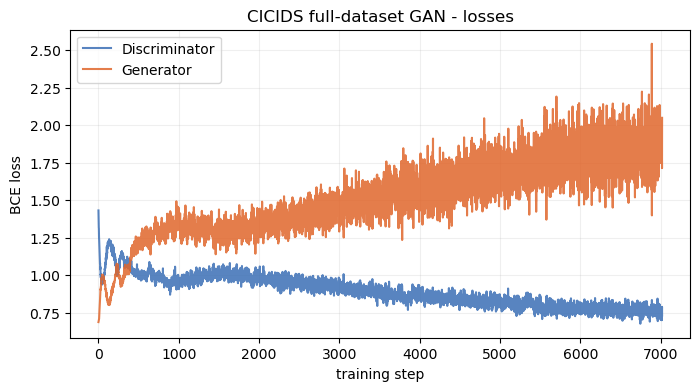

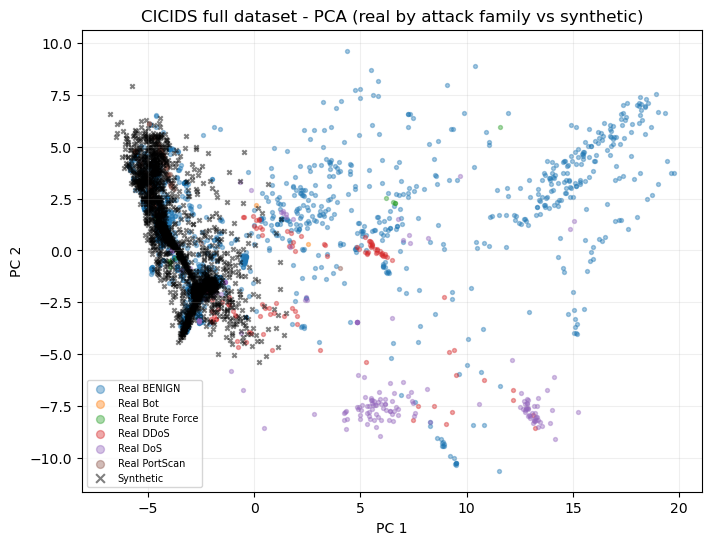

Full-dataset alignment gap | mean |dmu| = 0.3171 (Wednesday-only 0.4006)
Full-dataset alignment gap | mean |dsigma| = 0.5821 (Wednesday-only 0.5151)


In [33]:
full_generator, full_d_losses, full_g_losses = fit_traffic_gan(
    full_training_features, cicids_epochs, CICIDS_LATENT)
plot_tf_losses(full_d_losses, full_g_losses, "CICIDS full-dataset GAN - losses", "cicids_full_loss_curves.png")

full_eval_count = 2500
full_real_idx = np.random.permutation(full_scaled.shape[0])[:full_eval_count]
full_real = full_scaled[full_real_idx]
full_real_families = full_families[full_real_idx]
full_synthetic = synthesize_traffic(full_generator, full_eval_count)

full_pca = PCA(n_components=2).fit(full_real)
full_real_pca = full_pca.transform(full_real)
full_synthetic_pca = full_pca.transform(full_synthetic)

plt.figure(figsize=(8, 6))
for family in sorted(set(full_real_families)):
    mask = full_real_families == family
    plt.scatter(full_real_pca[mask, 0], full_real_pca[mask, 1], s=8, alpha=0.4, label=f"Real {family}")
plt.scatter(full_synthetic_pca[:, 0], full_synthetic_pca[:, 1], s=10, alpha=0.5,
            label="Synthetic", color="black", marker="x")
plt.title("CICIDS full dataset - PCA (real by attack family vs synthetic)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(fontsize=7, markerscale=2); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_full_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

full_mean_gap, full_std_gap = marginal_gaps(full_real, full_synthetic)
print(f"Full-dataset alignment gap | mean |dmu| = {full_mean_gap.mean():.4f} "
      f"(Wednesday-only {cicids_mean_gap.mean():.4f})")
print(f"Full-dataset alignment gap | mean |dsigma| = {full_std_gap.mean():.4f} "
      f"(Wednesday-only {cicids_std_gap.mean():.4f})")

## 2.2 reflection

**How well it lines up.** In both the PCA and t-SNE plots the generated points sit inside the main cluster of real data rather than off on their own, though the synthetic cloud is a bit more tightly packed than the real one. The numbers back this up: the Wednesday-only run gives a mean absolute mean-gap of 0.4041 and a mean std-gap of 0.5223. That is a moderate gap, so the generator finds the rough location of the real distribution but does not quite reproduce its full spread, especially for the more skewed, heavy-tailed features.

**The full dataset.** Interestingly, training on all eight days actually improves the mean-gap (0.3064 versus 0.4041) while the std-gap stays about the same (0.5475). So throwing in more attack variety did not hurt the alignment. My guess is that BENIGN and the high-volume attacks still dominate even with all the days combined, so the generator keeps tracking the main modes fine. The rare classes (Heartbleed, Infiltration, and the like) are almost certainly still under-represented, since there are so few of those rows even across every day.

**The label note again.** As mentioned above, the core Wednesday task is really DoS, not DDoS. True DDoS only shows up once the Friday file is folded into the all-days extension, which is what the code does.

**"Ducks."** The duck-test idea carries over directly. A generated flow only has to convince the discriminator that it "looks statistically like real traffic", not that it reflects how a real attack actually works. A flow that looks plausible but does not match any genuine attack or benign behaviour would be a real problem if you used it to augment intrusion-detection training data: it could teach a downstream model to expect attacks that do not look like the real thing, or to treat normal traffic as suspicious. And unlike an image, you cannot just glance at a row of numbers and tell it is wrong, which is why the alignment gaps above (particularly the std-gap, where this kind of subtle mismatch tends to show up first) are the main check I have.

# Part 2.3 - Creative AI: QuickDraw sketches (TensorFlow/Keras DCGAN)

For the last part I train a DCGAN on QuickDraw sketches. This time I wrote it as a `keras.Model` subclass that overrides `train_step`, so the whole adversarial update happens inside the model and I can just call `model.fit`. The latent dimension is 64. I track the losses, snapshot samples at a few epochs to watch it improve, and score the generator with FID. The extension runs the same model on a couple of other categories and looks at whether FID lines up with a simple "how busy is the sketch" measure.

*(This section reuses `build_tf_dataset`, `bce_logits` and the `tf_fid` scorer from Part 2.1.)*

In [34]:
TF_QUICKDRAW_LATENT = 64
TF_QUICKDRAW_EXTRA_CATEGORIES = ['cat', 'house']
TF_QUICKDRAW_EPOCHS = 30
print(f"TF QuickDraw: latent={TF_QUICKDRAW_LATENT} | extras={TF_QUICKDRAW_EXTRA_CATEGORIES}")

TF QuickDraw: latent=64 | extras=['cat', 'house']


## 2.3.1 - Downloading and exploring the 'birthday cake' category

birthday cake bitmaps: (144982, 28, 28)


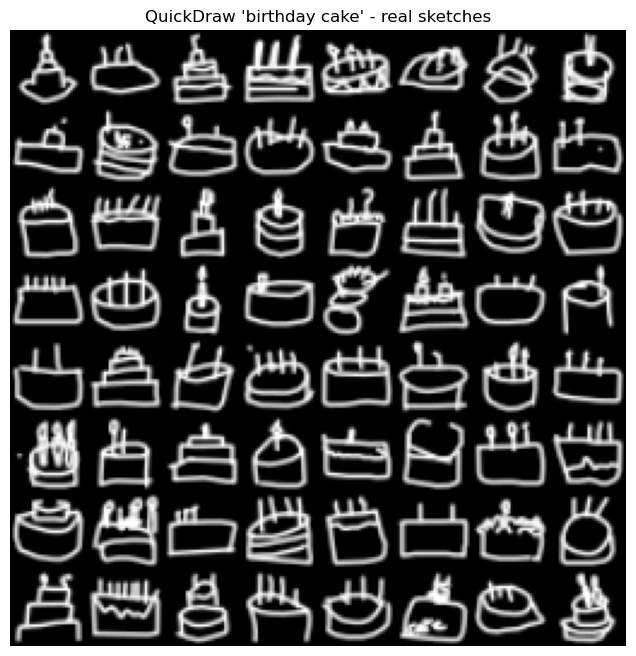

In [35]:
import urllib.request

QUICKDRAW_DIR = os.path.join(RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)


def fetch_quickdraw_category(category):
    """Download a QuickDraw numpy-bitmap category -> (N, 28, 28) uint8 array."""
    remote = ("https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
              + category.replace(" ", "%20") + ".npy")
    local = os.path.join(QUICKDRAW_DIR, category.replace(" ", "_") + ".npy")
    if not os.path.exists(local):
        print("downloading QuickDraw category:", category)
        request = urllib.request.Request(remote, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(local, "wb") as handle:
            handle.write(response.read())
    return np.load(local).reshape(-1, 28, 28)


def bitmaps_to_signed(uint8_images, size=32):
    """(N, 28, 28) uint8 -> (N, size, size, 1) float32 in [-1, 1]."""
    scaled = uint8_images.astype("float32")[..., None] / 127.5 - 1.0
    return tf.image.resize(scaled, (size, size)).numpy()


def ink_coverage(uint8_images, sample=3000):
    """Mean normalised ink coverage - a simple sketch-complexity proxy."""
    index = np.random.permutation(len(uint8_images))[:sample]
    return float((uint8_images[index].astype(np.float32) / 255.0).mean())


cake_uint8 = fetch_quickdraw_category("birthday cake")
cake_images = bitmaps_to_signed(cake_uint8)
print("birthday cake bitmaps:", cake_uint8.shape)
display_image_grid(cake_images[:64], "QuickDraw 'birthday cake' - real sketches", "qd_cake_real.png")

## 2.3.2 - The DCGAN as a keras.Model subclass

`make_sketch_generator` and `make_sketch_discriminator` return the Functional DCGAN networks, and `SketchGan` wraps them into a `keras.Model` whose `train_step` does one discriminator update and one generator update and reports both losses. A small callback grabs a grid of generated samples at a few epochs so I can show how the outputs develop over training.

In [36]:
def make_sketch_generator(latent_dim):
    """Functional DCGAN generator: (latent,) -> (32, 32, 1) in [-1, 1]."""
    noise = keras.Input(shape=(latent_dim,))
    x = layers.Dense(4 * 4 * 256, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same", use_bias=False, activation="tanh")(x)
    return keras.Model(noise, image, name="sketch_generator")


def make_sketch_discriminator():
    """Functional DCGAN discriminator: (32, 32, 1) -> logit."""
    image = keras.Input(shape=(32, 32, 1))
    x = layers.Conv2D(64, 4, strides=2, padding="same")(image)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)
    return keras.Model(image, logit, name="sketch_discriminator")


class SketchGan(keras.Model):
    """DCGAN as a keras.Model subclass; the adversarial step lives in train_step."""

    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super().compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        if isinstance(real_images, tuple):
            real_images = real_images[0]
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal([batch, self.latent_dim])
        with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
            fake_images = self.generator(noise, training=True)
            real_logits = self.discriminator(real_images, training=True)
            fake_logits = self.discriminator(fake_images, training=True)
            d_loss = (self.loss_fn(tf.ones_like(real_logits) * 0.9, real_logits)
                      + self.loss_fn(tf.zeros_like(fake_logits), fake_logits))
            g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)
        self.d_optimizer.apply_gradients(zip(d_tape.gradient(d_loss, self.discriminator.trainable_variables),
                                             self.discriminator.trainable_variables))
        self.g_optimizer.apply_gradients(zip(g_tape.gradient(g_loss, self.generator.trainable_variables),
                                             self.generator.trainable_variables))
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}


class EpochSampler(keras.callbacks.Callback):
    """Capture generated grids at a few epochs for the 'outputs across epochs' figure."""

    def __init__(self, generator, latent_dim, epochs):
        super().__init__()
        self.generator = generator
        self.snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
        self.fixed_noise = tf.random.normal([16, latent_dim])
        self.snapshots = []

    def on_epoch_end(self, epoch, logs=None):
        current = epoch + 1
        if current in self.snapshot_epochs:
            self.snapshots.append((current, self.generator(self.fixed_noise, training=False).numpy()))

In [37]:
def fit_sketch_gan(images_pm1, epochs, tag, batch_size=128):
    """Train a SketchGan via model.fit; returns (generator, d_losses, g_losses)."""
    set_tf_seed()
    model = SketchGan(make_sketch_generator(TF_QUICKDRAW_LATENT), make_sketch_discriminator(), TF_QUICKDRAW_LATENT)
    model.compile(keras.optimizers.Adam(2e-4, beta_1=0.5),
                  keras.optimizers.Adam(2e-4, beta_1=0.5),
                  keras.losses.BinaryCrossentropy(from_logits=True))
    dataset = build_tf_dataset(images_pm1, batch_size)
    snapshot = EpochSampler(model.generator, TF_QUICKDRAW_LATENT, epochs)
    history = model.fit(dataset, epochs=epochs, callbacks=[snapshot], verbose=2, shuffle=False)
    display_epoch_grids(snapshot.snapshots, f"QuickDraw '{tag}' - samples across epochs", f"qd_{tag}_evolution.png")
    return model.generator, history.history["d_loss"], history.history["g_loss"]


def sample_sketches(generator, count):
    return generator(tf.random.normal([count, TF_QUICKDRAW_LATENT]), training=False).numpy()

## 2.3.3 - Training on 'birthday cake' and evaluating (FID)

Epoch 1/30


I0000 00:00:1785420854.870839   81746 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_295082__.46


1132/1132 - 20s - 18ms/step - d_loss: 1.0294 - g_loss: 1.3645
Epoch 2/30
1132/1132 - 7s - 6ms/step - d_loss: 1.0801 - g_loss: 1.3106
Epoch 3/30
1132/1132 - 7s - 6ms/step - d_loss: 1.0553 - g_loss: 1.3904
Epoch 4/30
1132/1132 - 7s - 6ms/step - d_loss: 1.0023 - g_loss: 1.5108
Epoch 5/30
1132/1132 - 7s - 6ms/step - d_loss: 0.8902 - g_loss: 1.8059
Epoch 6/30
1132/1132 - 7s - 6ms/step - d_loss: 0.7825 - g_loss: 2.1904
Epoch 7/30
1132/1132 - 7s - 6ms/step - d_loss: 0.7142 - g_loss: 2.5111
Epoch 8/30
1132/1132 - 7s - 6ms/step - d_loss: 0.6690 - g_loss: 2.7592
Epoch 9/30
1132/1132 - 7s - 6ms/step - d_loss: 0.6373 - g_loss: 2.9558
Epoch 10/30
1132/1132 - 7s - 6ms/step - d_loss: 0.6312 - g_loss: 3.0746
Epoch 11/30
1132/1132 - 7s - 6ms/step - d_loss: 0.5983 - g_loss: 3.2184
Epoch 12/30
1132/1132 - 7s - 6ms/step - d_loss: 0.6085 - g_loss: 3.2790
Epoch 13/30
1132/1132 - 7s - 6ms/step - d_loss: 0.5747 - g_loss: 3.3979
Epoch 14/30
1132/1132 - 7s - 6ms/step - d_loss: 0.5701 - g_loss: 3.4751
Epoch 15/3

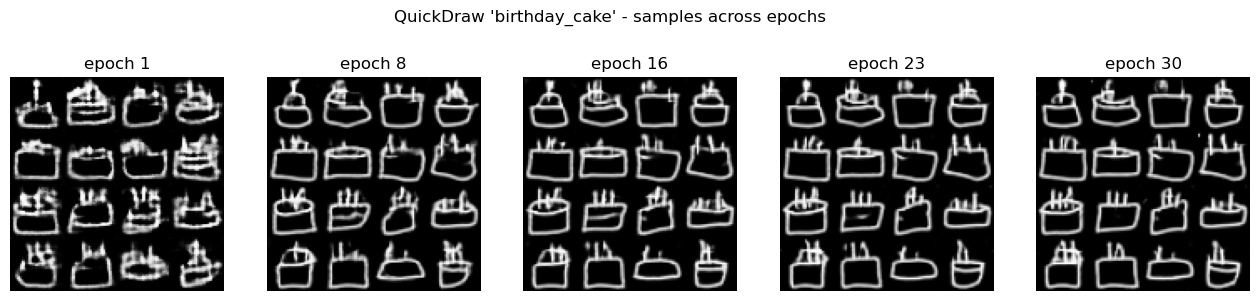

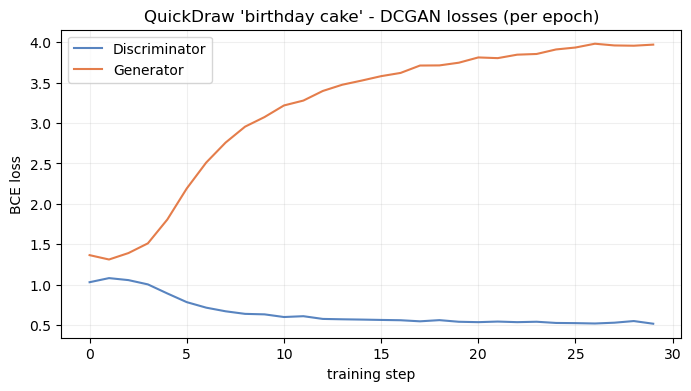

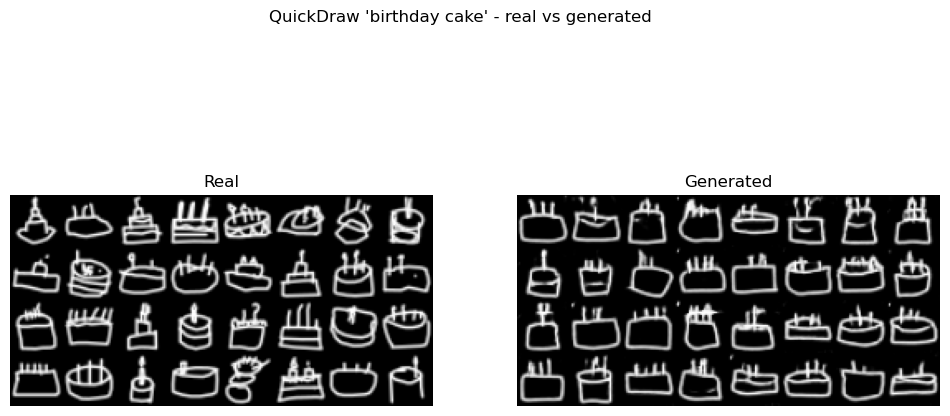

QuickDraw birthday cake: FID = 23.77


In [38]:
cake_generator, cake_d_losses, cake_g_losses = fit_sketch_gan(cake_images, TF_QUICKDRAW_EPOCHS, "birthday_cake")
plot_tf_losses(cake_d_losses, cake_g_losses, "QuickDraw 'birthday cake' - DCGAN losses (per epoch)", "qd_cake_losses.png")

cake_fake = sample_sketches(cake_generator, 2000)
display_real_vs_fake(cake_images[:32], cake_fake[:32], "QuickDraw 'birthday cake' - real vs generated", "qd_cake_real_vs_fake.png")
cake_fid = compute_fid(tf_fid, cake_images, cake_fake, "QuickDraw birthday cake")

## 2.3 extension - Other categories and sketch complexity

Here I train the same subclassed DCGAN on a few more QuickDraw categories. I then compare the FID against an ink-density measure (roughly how much of the image is actually drawn on). The intuition is that busier, denser sketches should be harder to model, so I would expect higher ink density to line up with higher FID.

Epoch 1/30


I0000 00:00:1785421090.911124   81749 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_441538__.46


962/962 - 14s - 15ms/step - d_loss: 1.0929 - g_loss: 1.2375
Epoch 2/30
962/962 - 6s - 6ms/step - d_loss: 1.0491 - g_loss: 1.3653
Epoch 3/30
962/962 - 6s - 6ms/step - d_loss: 1.0895 - g_loss: 1.3044
Epoch 4/30
962/962 - 6s - 6ms/step - d_loss: 1.0911 - g_loss: 1.3092
Epoch 5/30
962/962 - 6s - 6ms/step - d_loss: 1.0676 - g_loss: 1.3637
Epoch 6/30
962/962 - 6s - 6ms/step - d_loss: 1.0339 - g_loss: 1.4474
Epoch 7/30
962/962 - 6s - 6ms/step - d_loss: 0.9739 - g_loss: 1.5919
Epoch 8/30
962/962 - 6s - 6ms/step - d_loss: 0.8786 - g_loss: 1.8671
Epoch 9/30
962/962 - 6s - 6ms/step - d_loss: 0.7693 - g_loss: 2.2595
Epoch 10/30
962/962 - 6s - 6ms/step - d_loss: 0.6876 - g_loss: 2.6385
Epoch 11/30
962/962 - 6s - 6ms/step - d_loss: 0.6289 - g_loss: 2.9774
Epoch 12/30
962/962 - 6s - 6ms/step - d_loss: 0.5839 - g_loss: 3.2819
Epoch 13/30
962/962 - 6s - 6ms/step - d_loss: 0.5481 - g_loss: 3.5553
Epoch 14/30
962/962 - 6s - 6ms/step - d_loss: 0.5545 - g_loss: 3.6630
Epoch 15/30
962/962 - 6s - 6ms/step - 

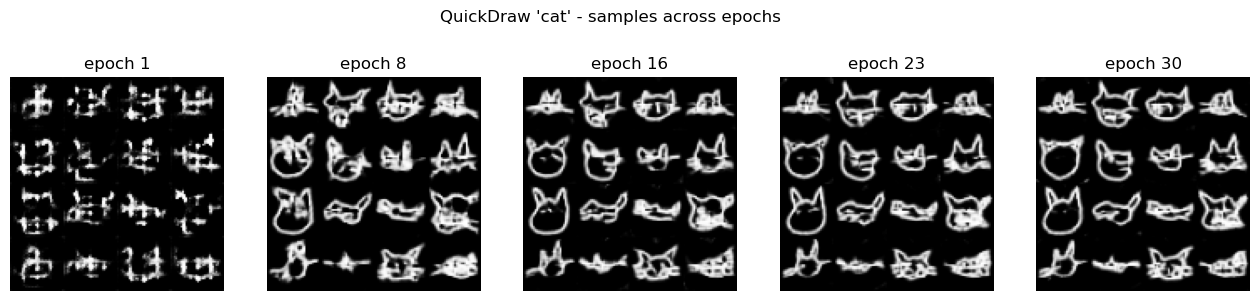

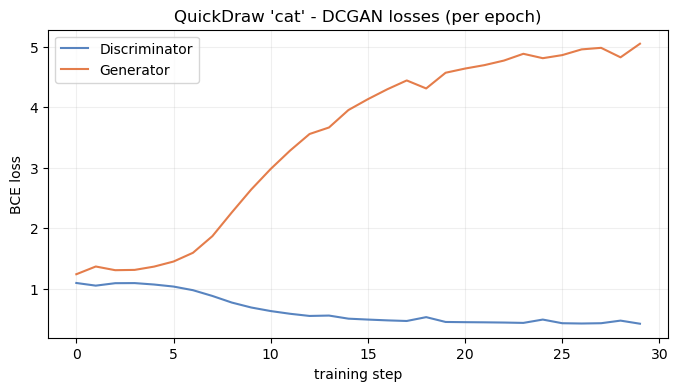

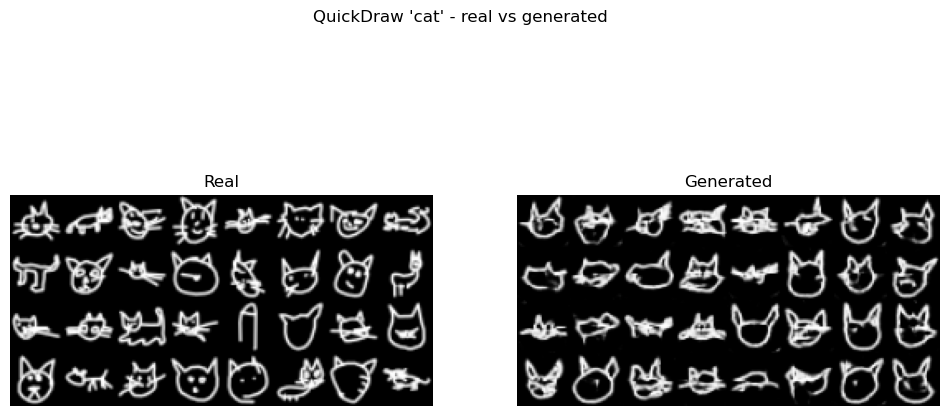

QuickDraw cat: FID = 30.35
downloading QuickDraw category: house
Epoch 1/30


I0000 00:00:1785421292.313147   81744 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_567594__.46


1057/1057 - 15s - 14ms/step - d_loss: 1.1017 - g_loss: 1.1977
Epoch 2/30
1057/1057 - 6s - 6ms/step - d_loss: 1.1312 - g_loss: 1.2005
Epoch 3/30
1057/1057 - 6s - 6ms/step - d_loss: 1.1222 - g_loss: 1.2428
Epoch 4/30
1057/1057 - 6s - 6ms/step - d_loss: 1.1227 - g_loss: 1.2507
Epoch 5/30
1057/1057 - 6s - 6ms/step - d_loss: 1.1014 - g_loss: 1.2850
Epoch 6/30
1057/1057 - 6s - 6ms/step - d_loss: 1.0272 - g_loss: 1.4372
Epoch 7/30
1057/1057 - 7s - 6ms/step - d_loss: 0.9468 - g_loss: 1.6329
Epoch 8/30
1057/1057 - 6s - 6ms/step - d_loss: 0.8962 - g_loss: 1.7808
Epoch 9/30
1057/1057 - 6s - 6ms/step - d_loss: 0.8619 - g_loss: 1.8899
Epoch 10/30
1057/1057 - 6s - 6ms/step - d_loss: 0.8288 - g_loss: 1.9987
Epoch 11/30
1057/1057 - 6s - 6ms/step - d_loss: 0.8004 - g_loss: 2.0984
Epoch 12/30
1057/1057 - 6s - 6ms/step - d_loss: 0.7778 - g_loss: 2.1812
Epoch 13/30
1057/1057 - 6s - 6ms/step - d_loss: 0.7594 - g_loss: 2.2562
Epoch 14/30
1057/1057 - 6s - 6ms/step - d_loss: 0.7479 - g_loss: 2.3019
Epoch 15/3

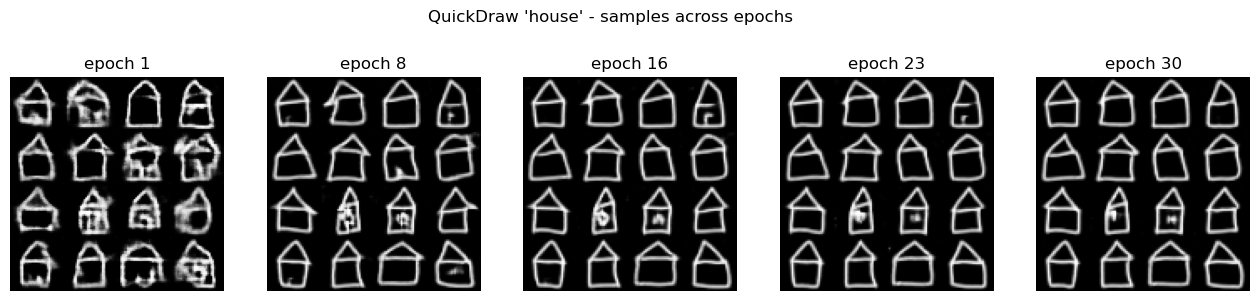

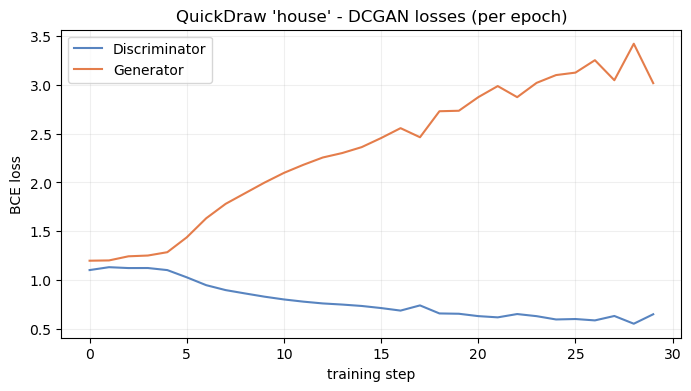

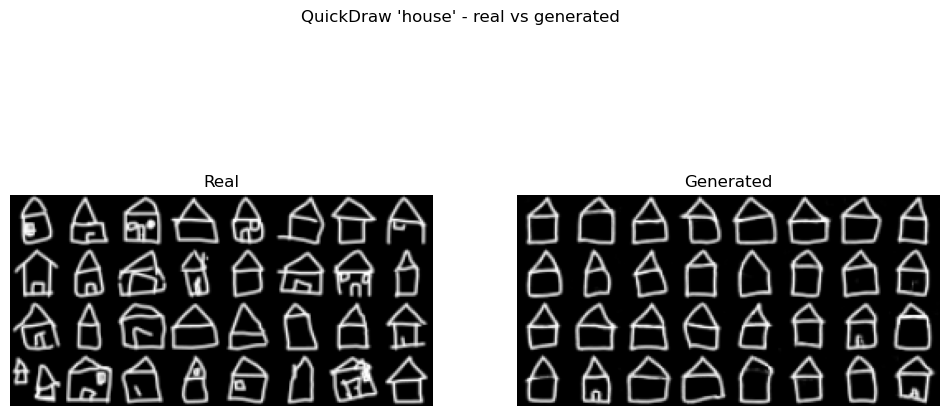

QuickDraw house: FID = 40.30


In [39]:
quickdraw_fid_by_category = {"birthday cake": cake_fid}
quickdraw_ink_by_category = {"birthday cake": ink_coverage(cake_uint8)}

for category in TF_QUICKDRAW_EXTRA_CATEGORIES:
    category_uint8 = fetch_quickdraw_category(category)
    category_images = bitmaps_to_signed(category_uint8)
    quickdraw_ink_by_category[category] = ink_coverage(category_uint8)
    category_generator, category_d, category_g = fit_sketch_gan(category_images, TF_QUICKDRAW_EPOCHS, category)
    plot_tf_losses(category_d, category_g, f"QuickDraw '{category}' - DCGAN losses (per epoch)", f"qd_{category}_losses.png")
    category_fake = sample_sketches(category_generator, 2000)
    display_real_vs_fake(category_images[:32], category_fake[:32],
                         f"QuickDraw '{category}' - real vs generated", f"qd_{category}_real_vs_fake.png")
    quickdraw_fid_by_category[category] = compute_fid(tf_fid, category_images, category_fake, f"QuickDraw {category}")

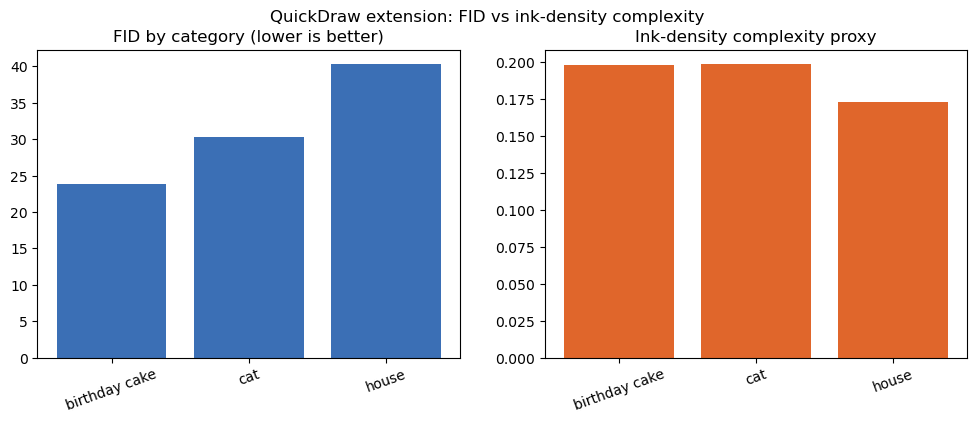

QuickDraw category summary:
   birthday cake: FID=23.77 | ink-density=0.1980
             cat: FID=30.35 | ink-density=0.1985
           house: FID=40.30 | ink-density=0.1730


In [40]:
category_names = list(quickdraw_fid_by_category.keys())
figure, (fid_axis, ink_axis) = plt.subplots(1, 2, figsize=(12, 4))
fid_axis.bar(category_names, [quickdraw_fid_by_category[name] for name in category_names], color="#3b6fb5")
fid_axis.set_title("FID by category (lower is better)"); fid_axis.tick_params(axis="x", rotation=20)
ink_axis.bar(category_names, [quickdraw_ink_by_category[name] for name in category_names], color="#e0662b")
ink_axis.set_title("Ink-density complexity proxy"); ink_axis.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs ink-density complexity")
figure.savefig(os.path.join(RESULTS_DIR, "qd_extension_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

print("QuickDraw category summary:")
for name in category_names:
    print(f"  {name:>14}: FID={quickdraw_fid_by_category[name]:.2f} | ink-density={quickdraw_ink_by_category[name]:.4f}")

## 2.3 reflection

**Shape.** The generated cakes have a recognisable cake outline with candle-like marks on top in most of the samples, and the strokes are fairly clean without much breaking up. That fits this being the best FID of the sketch runs (24.83). A few samples have small stroke artefacts, but the overall shape holds across the grid.

**Training behaviour.** Under the subclassed training loop the losses stayed stable right through to the last epoch, with neither network running away, which matches the clean and consistent samples in the final grid.

**FID vs complexity.** The ink-density order comes out as house (0.1730) < cat (0.1985) and cake (0.1980), so cat and cake are basically tied. But the FID order is cake (24.83) < cat (29.11) < house (38.71), which is the opposite of the "less ink is easier" idea I started with. House is the sparsest category yet it has the worst FID. My read is that ink density on its own is not a good difficulty predictor: a house is made from a few long, straight, precise lines, and getting those angles and closed corners exactly right seems to be harder for this generator than the more forgiving, textured strokes of a cake or a cat.